End-to-End Insurance Risk Analytics & Predictive Modeling week_3

In [1]:
from pathlib import Path
import pandas as pd
import sys
# Set project root
project_root = Path().resolve().parent  # assumes notebook is inside 'notebooks'
# Set data path properly
data_path = project_root / "data" / "MachineLearningRating_v3.csv"  # check your file name!
sys.path.append(str(project_root))

In [5]:
from src.data_processing.data_loader import load_data
from src.data_processing.data_summary import DataSummary

1 Data Summarization

In [ ]:
df = load_data(data_path)
summary = DataSummary(df)
summary.df.info()   

TypeError: load_data() got an unexpected keyword argument 'engine'

In [10]:
summary.null_values()

NameError: name 'summary' is not defined

In [5]:
summary.unique_values()

UnderwrittenCoverID         116532
TotalPremium                 38959
CalculatedPremiumPerTerm     19869
PolicyID                      7000
SumInsured                    2186
TotalClaims                   1615
CapitalOutstanding            1030
CustomValueEstimate            923
PostalCode                     888
mmcode                         427
Model                          411
VehicleIntroDate               174
cubiccapacity                  122
kilowatts                       82
make                            46
SubCrestaZone                   45
CoverCategory                   28
RegistrationYear                25
TransactionMonth                23
CoverType                       22
MainCrestaZone                  16
CoverGroup                      14
ExcessSelected                  13
bodytype                        13
Bank                            11
Province                         9
Cylinders                        7
NumberOfDoors                    6
LegalType           

In [17]:
summary.describe()

,count,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.0,1.048175e+05,6.329371e+04,1.000000e+00,5.514300e+04,9.408300e+04,1.391900e+05,3.011750e+05
PolicyID,1000098.0,7.956682e+03,5.290039e+03,1.400000e+01,4.500000e+03,7.071000e+03,1.107700e+04,2.324600e+04
PostalCode,1000098.0,3.020601e+03,2.649854e+03,1.000000e+00,8.270000e+02,2.000000e+03,4.180000e+03,9.870000e+03
mmcode,999546.0,5.487770e+07,1.360381e+07,4.041200e+06,6.005692e+07,6.005842e+07,6.005842e+07,6.506535e+07
RegistrationYear,1000098.0,2.010225e+03,3.261391e+00,1.987000e+03,2.008000e+03,2.011000e+03,2.013000e+03,2.015000e+03
Cylinders,999546.0,4.046642e+00,2.940201e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,1.000000e+01
cubiccapacity,999546.0,2.466743e+03,4.428006e+02,0.000000e+00,2.237000e+03,2.694000e+03,2.694000e+03,1.288000e+04
kilowatts,999546.0,9.720792e+01,1.939326e+01,0.000000e+00,7.500000e+01,1.110000e+02,1.110000e+02,3.090000e+02
NumberOfDoors,999546.0,4.019250e+00,4.683144e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,6.000000e+00
CustomValueEstimate,220456.0,2.255311e+05,5.645157e+05,2.000000e+04,1.350000e+05,2.200000e+05,2.800000e+05,2.655000e+07


2 Data cleaning

In [4]:
from src.data_processing.data_cleaner import DataCleaner

cleaner = DataCleaner(df)
df_cleaned = cleaner.full_clean()
df_cleaned.to_csv("../data/cleaned_data.csv", index=False)
df_cleaned.head()


E:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\src\data_processing\data_cleaner.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df[col] = pd.to_datetime(self.df[col], errors="coerce")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


3 descriptive statics for numerical columns

In [7]:
from src.data_processing.descriptive import DescriptiveAnalyzer

# Create analyzer object
analyzer = DescriptiveAnalyzer(df_cleaned)

# Print everything
an_stats = analyzer.summarize()


📌 DESCRIPTIVE STATISTICS

       cubiccapacity     kilowatts  NumberOfDoors  CustomValueEstimate  \
count   1.000098e+06  1.000098e+06   1.000098e+06         1.000098e+06   
mean    2.465382e+03  9.715427e+01   4.017031e+00         4.971482e+04   
std     4.464536e+02  1.952187e+01   4.776073e-01         2.810481e+05   
min     0.000000e+00  0.000000e+00   0.000000e+00         0.000000e+00   
25%     2.237000e+03  7.500000e+01   4.000000e+00         0.000000e+00   
50%     2.694000e+03  1.110000e+02   4.000000e+00         0.000000e+00   
75%     2.694000e+03  1.110000e+02   4.000000e+00         0.000000e+00   
max     1.288000e+04  3.090000e+02   6.000000e+00         2.655000e+07   

       CapitalOutstanding    SumInsured  TermFrequency  \
count        1.000098e+06  1.000098e+06      1000098.0   
mean         5.258828e+04  6.041727e+05            0.0   
std          1.114033e+05  1.508332e+06            0.0   
min         -2.000000e+00  1.000000e-02            0.0   
25%          0.0

In [8]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 51 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  category      
 1   PolicyID                  1000098 non-null  category      
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  category      
 4   Citizenship               1000098 non-null  category      
 5   LegalType                 1000098 non-null  category      
 6   Title                     1000098 non-null  category      
 7   Language                  1000098 non-null  category      
 8   Bank                      1000098 non-null  category      
 9   AccountType               1000098 non-null  category      
 10  MaritalStatus             1000098 non-null  category      
 11  Gender                    1000098 non-null  catego

4 Univariate Analysis

📌 Plotting ALL numerical columns...


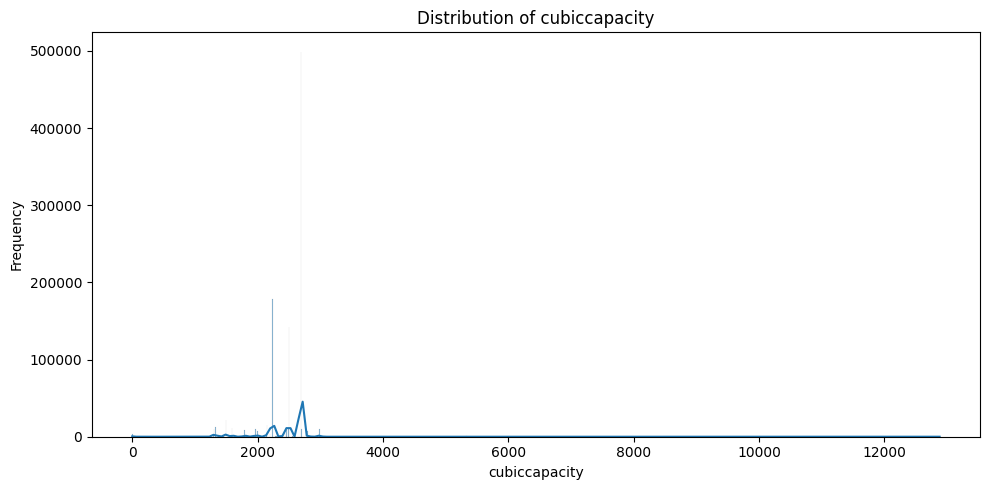

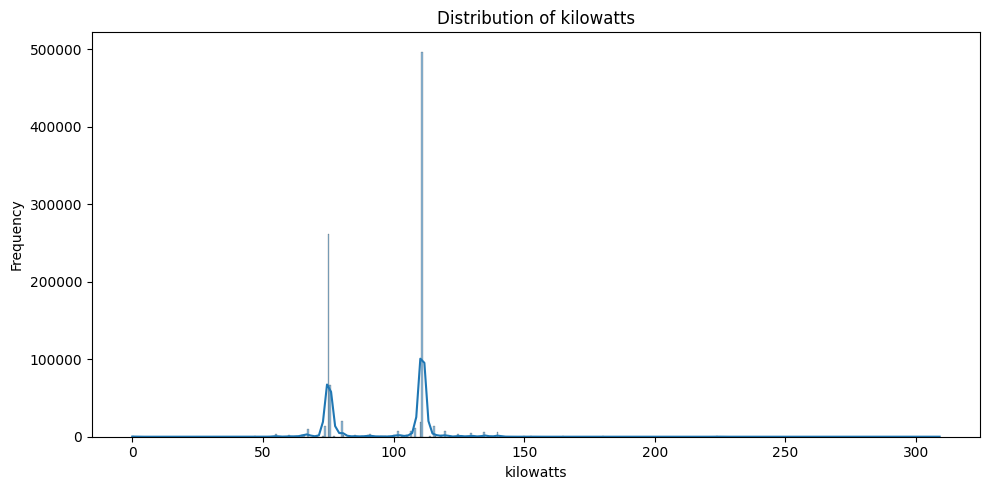

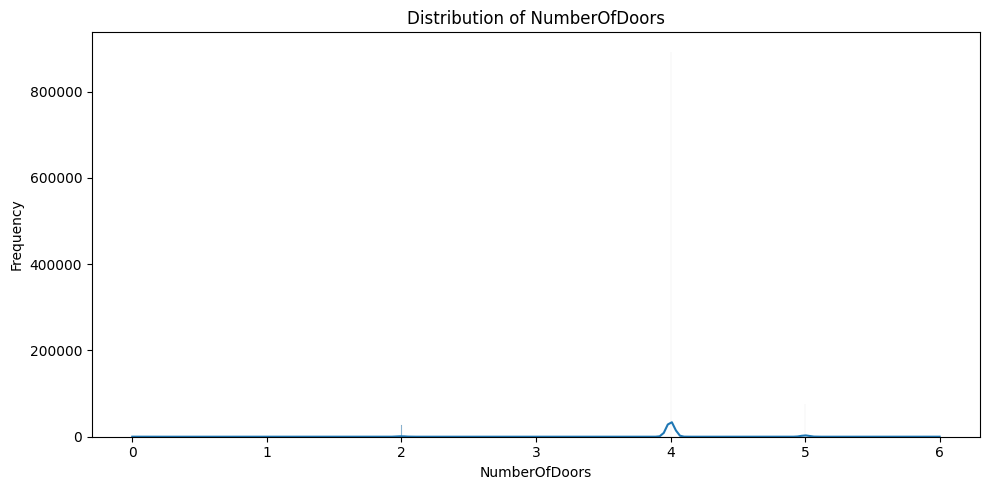

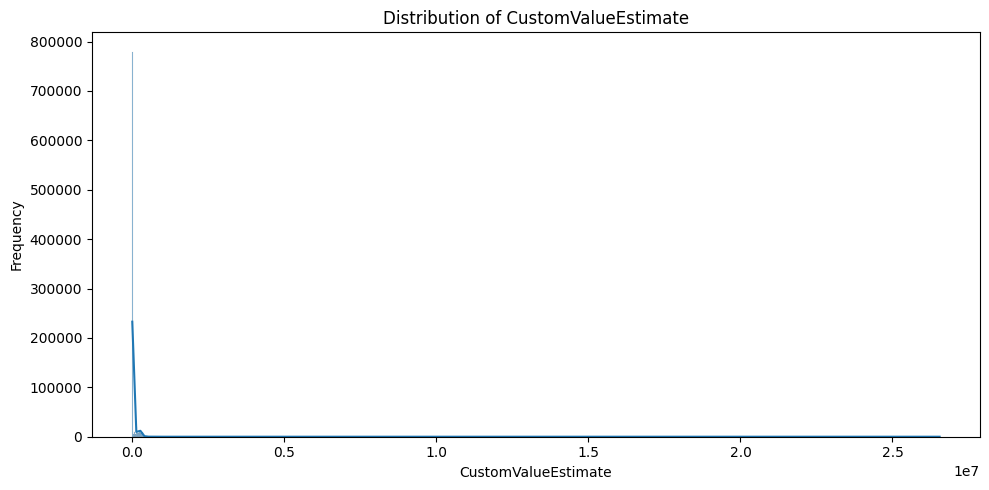

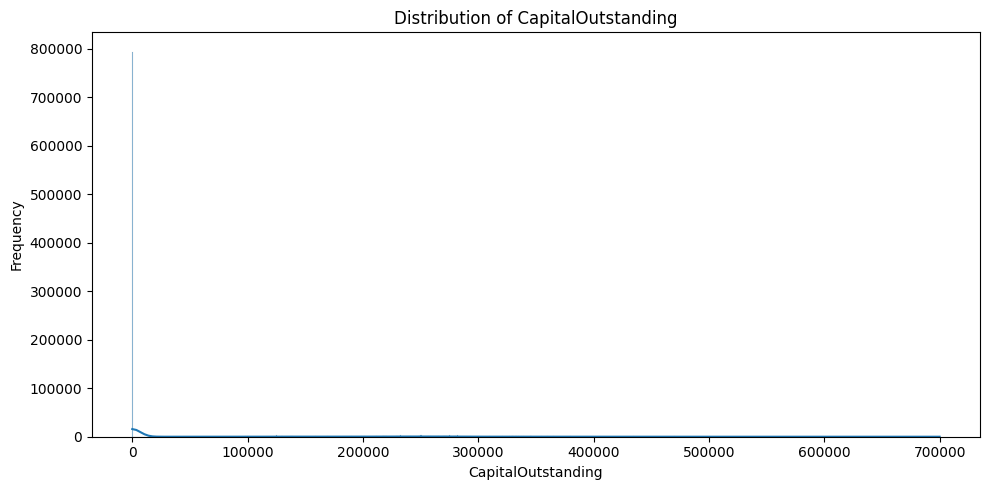

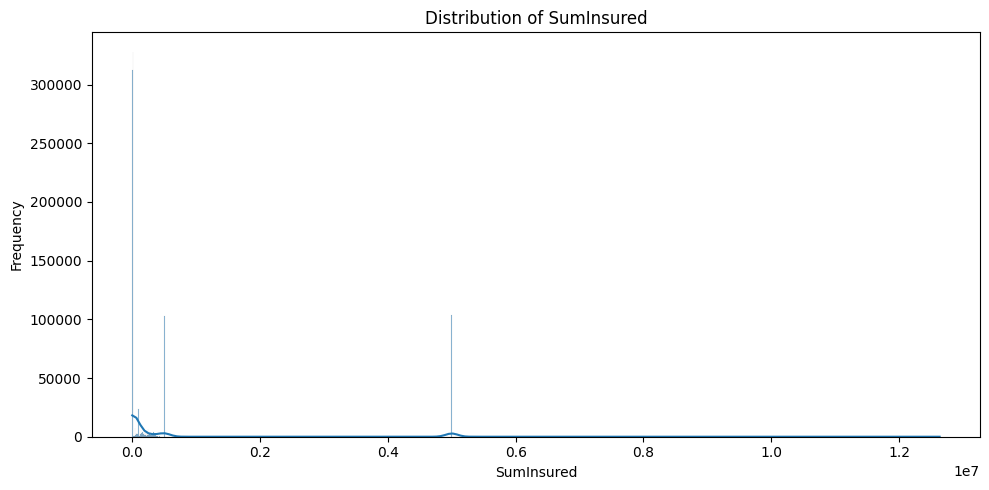

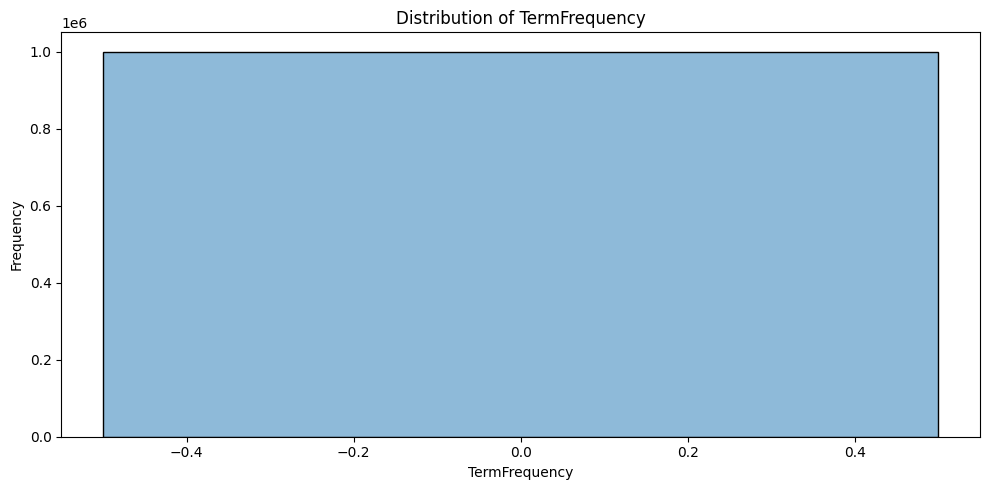

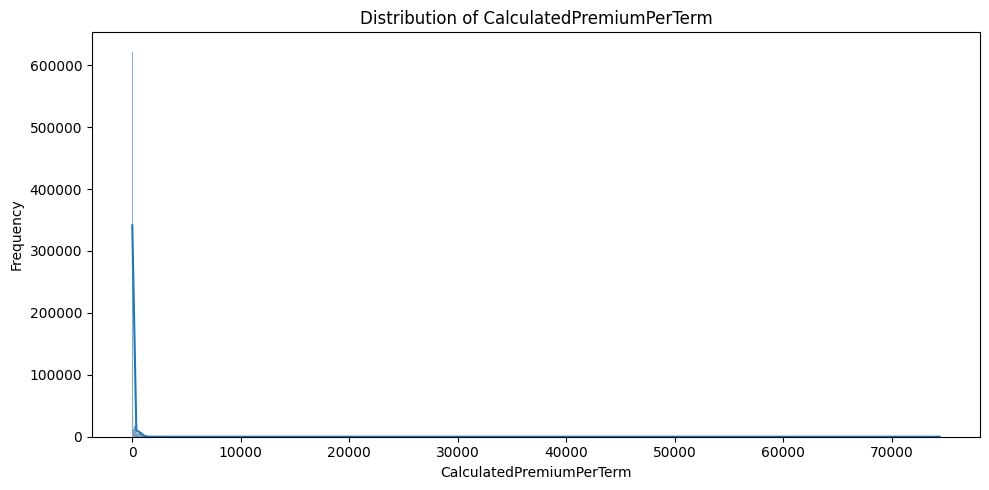

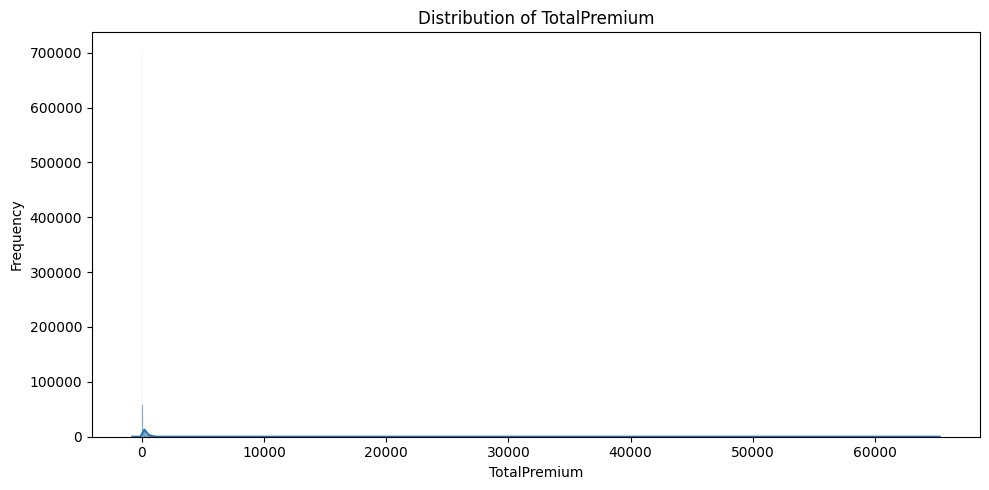

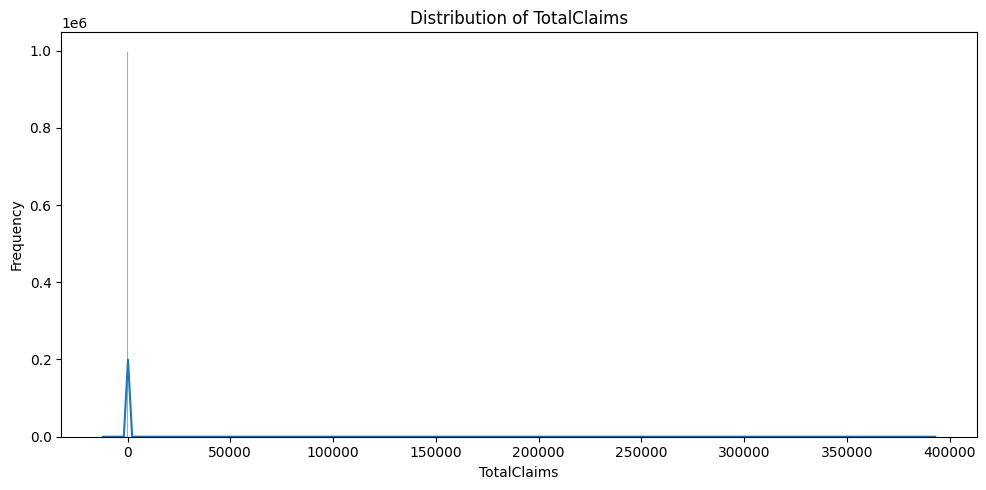

📌 Plotting ALL categorical columns...


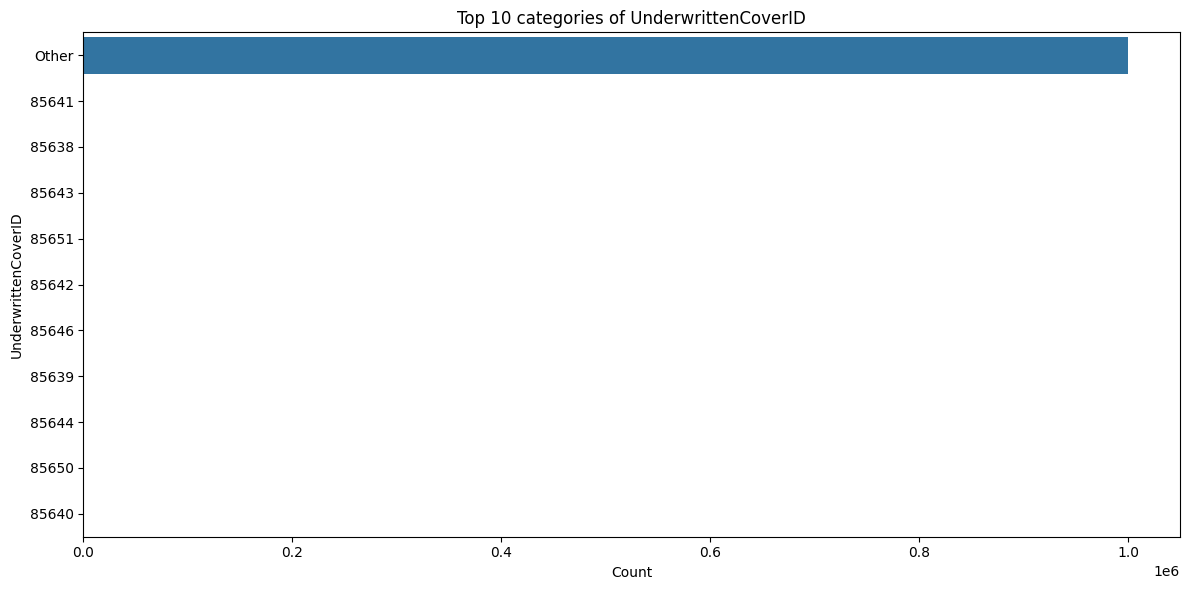

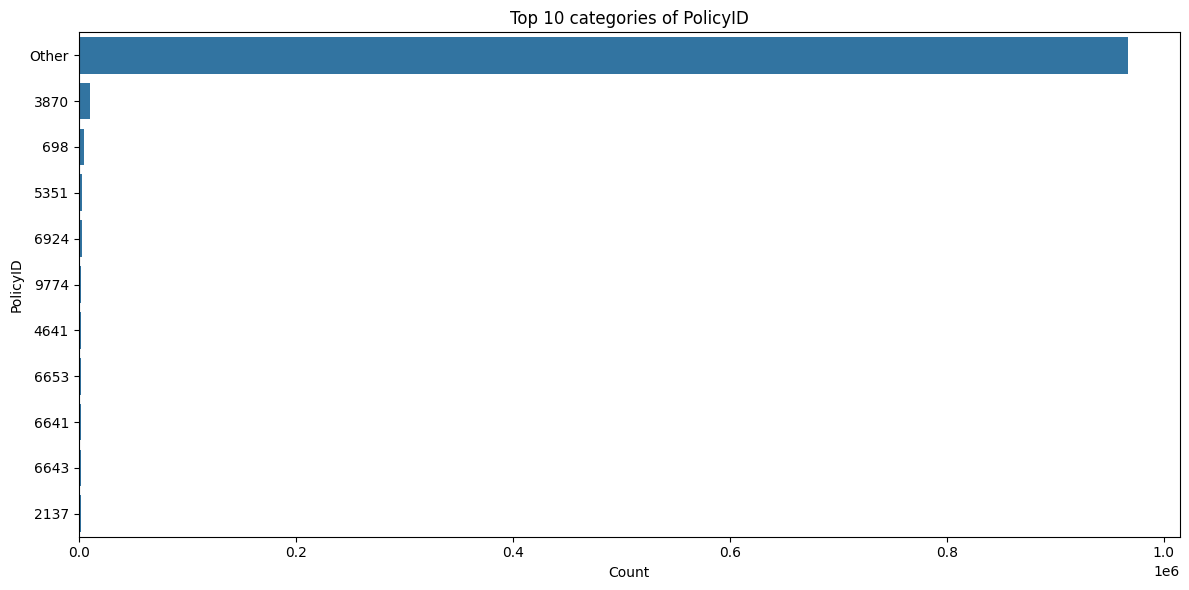

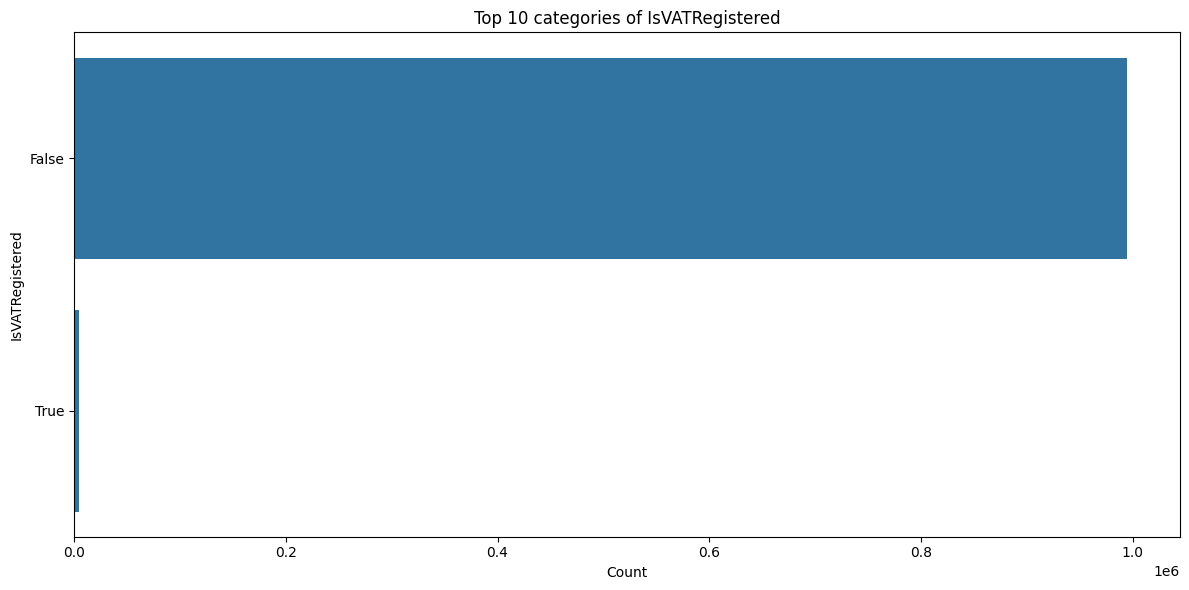

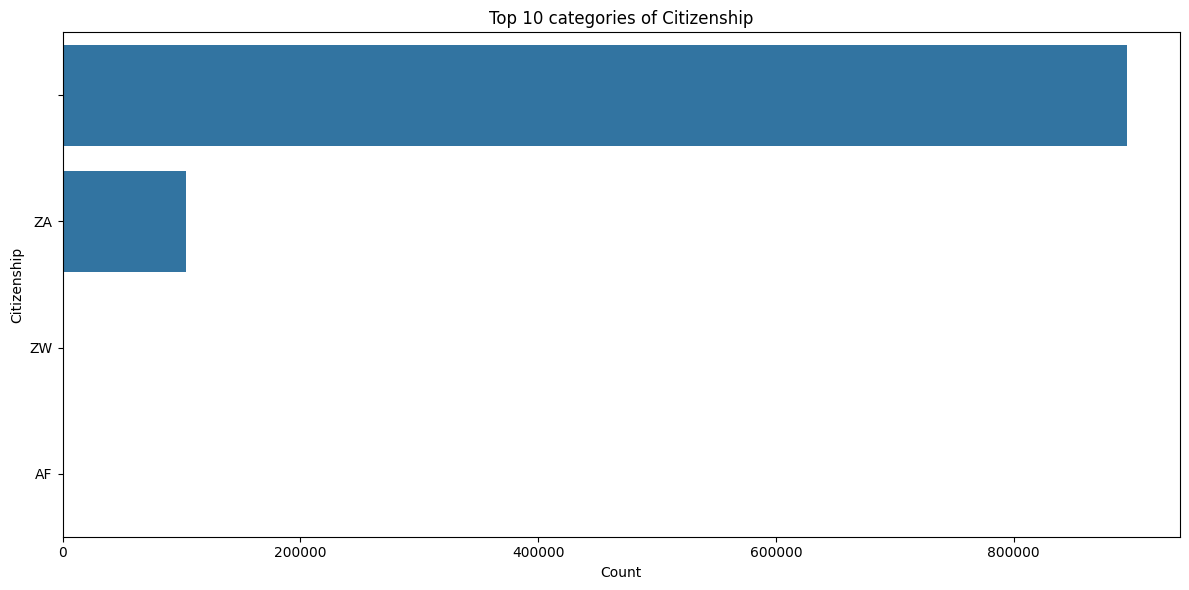

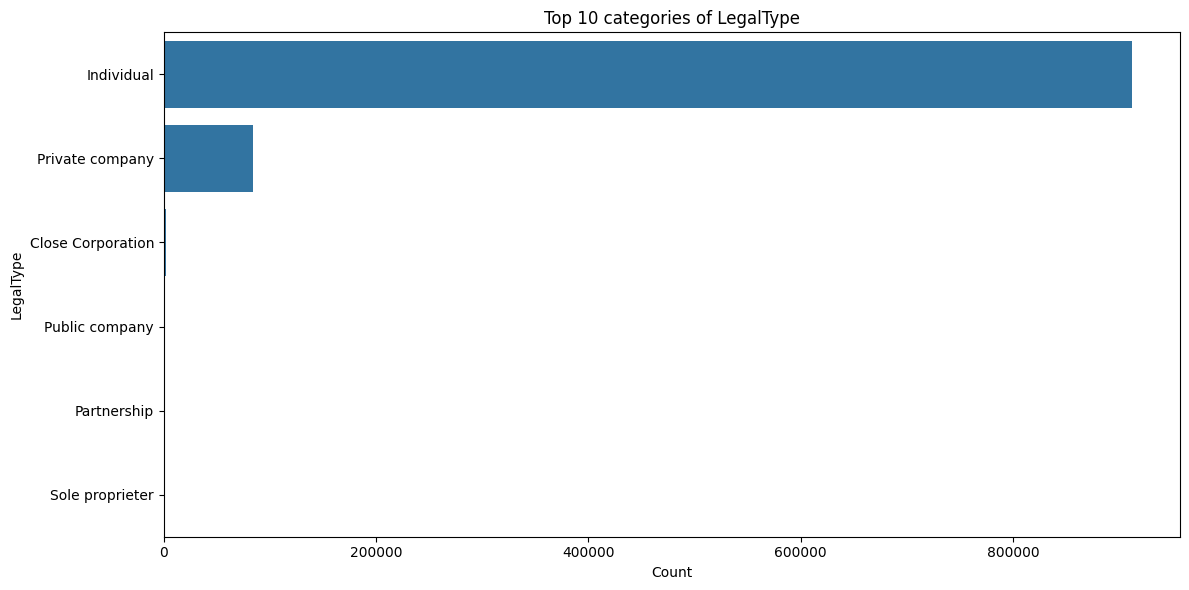

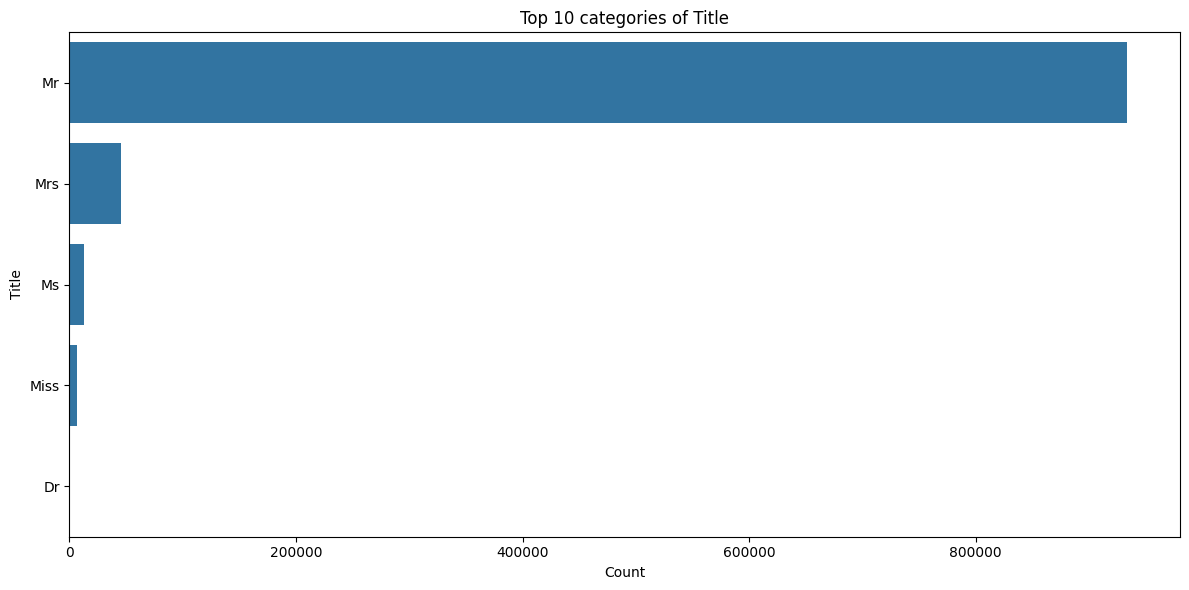

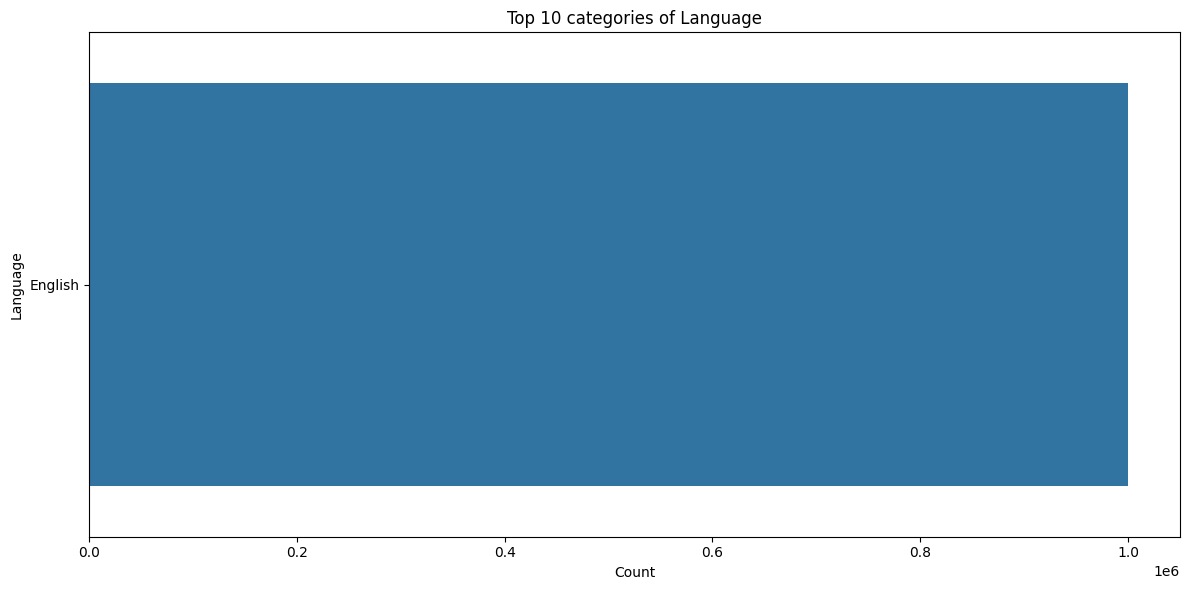

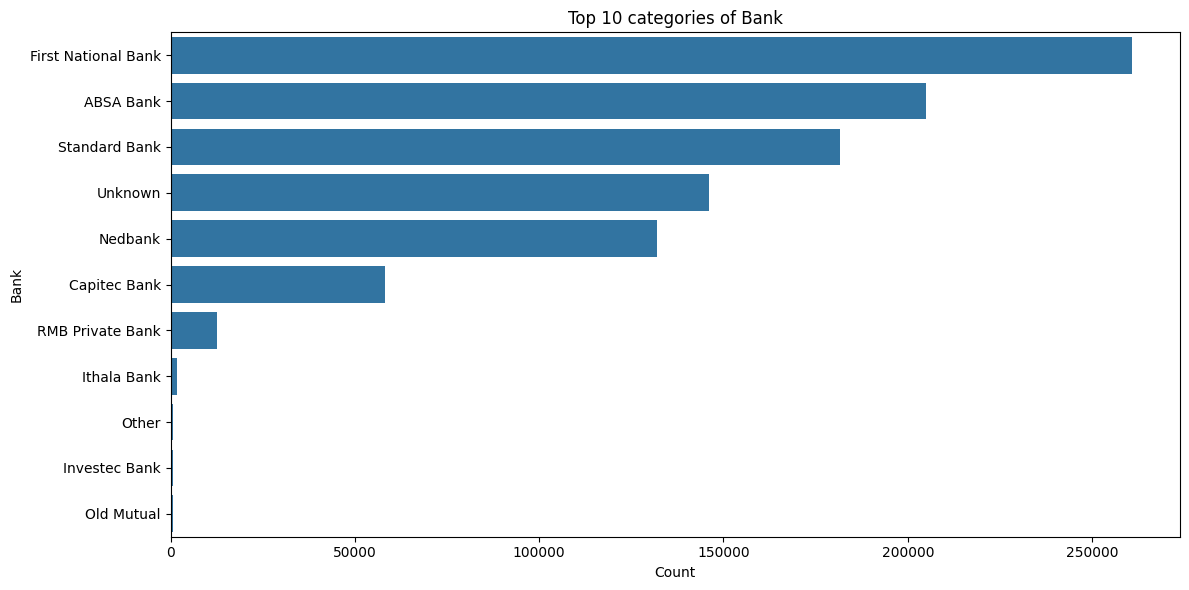

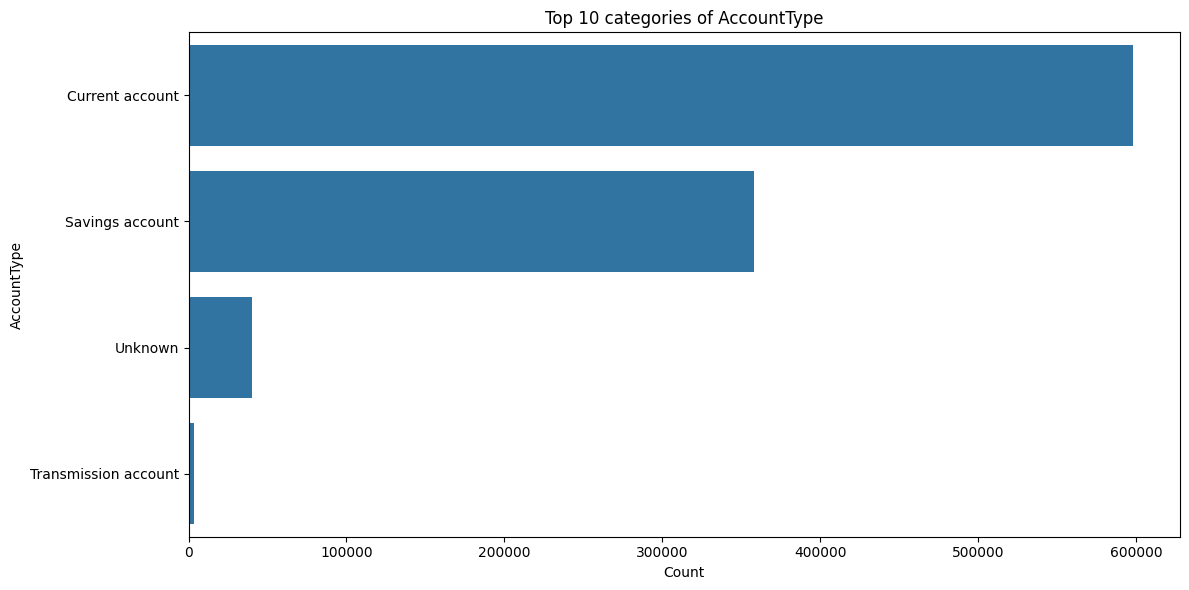

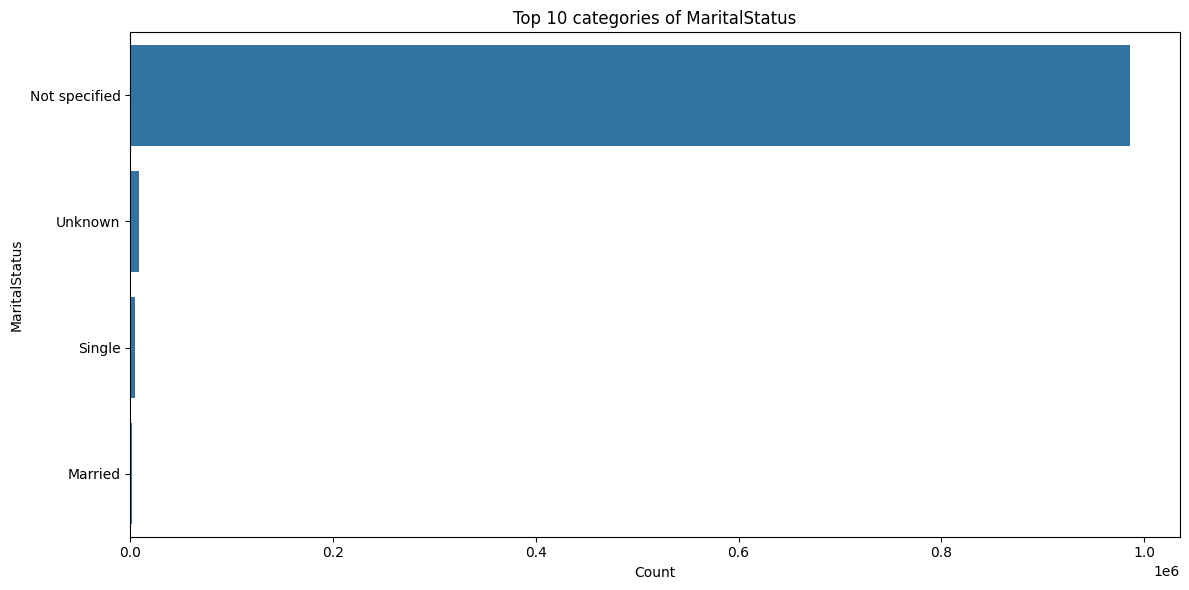

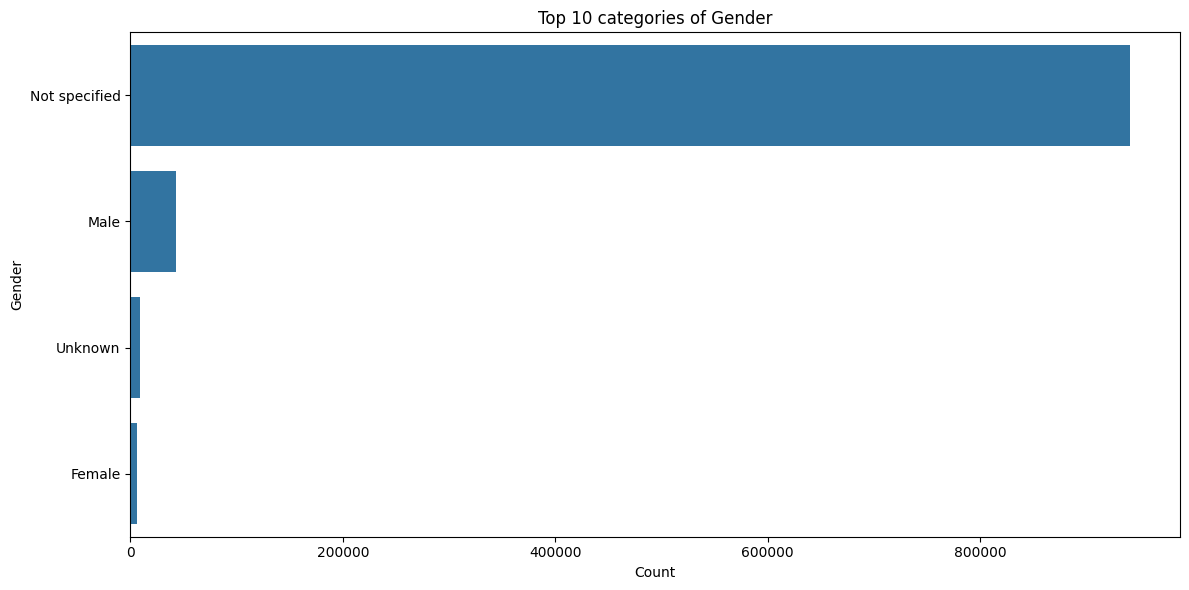

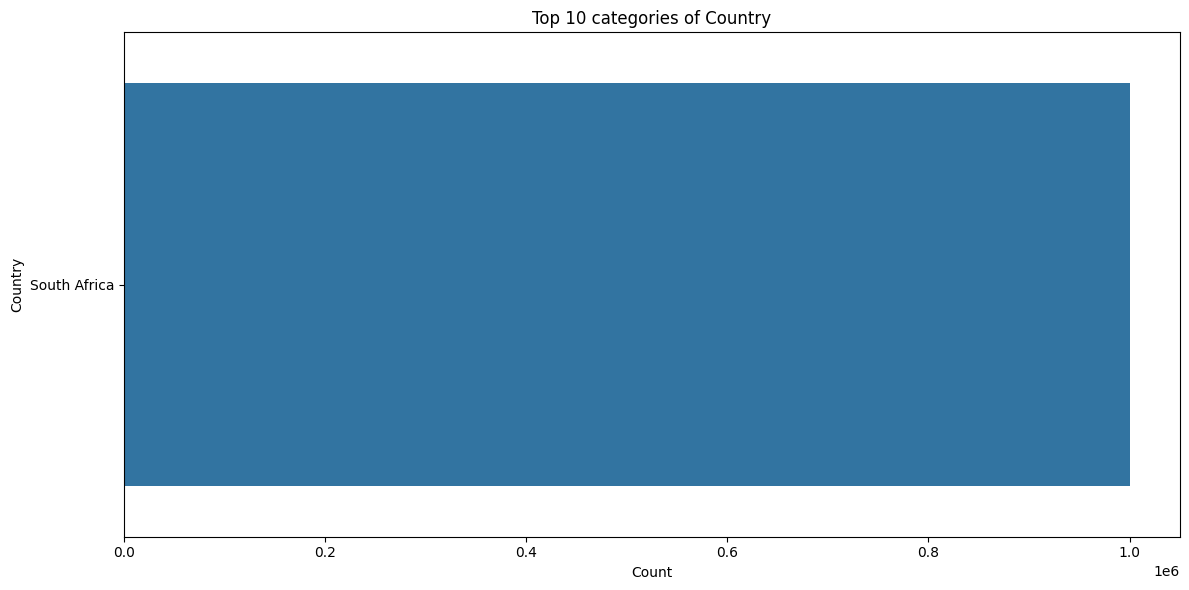

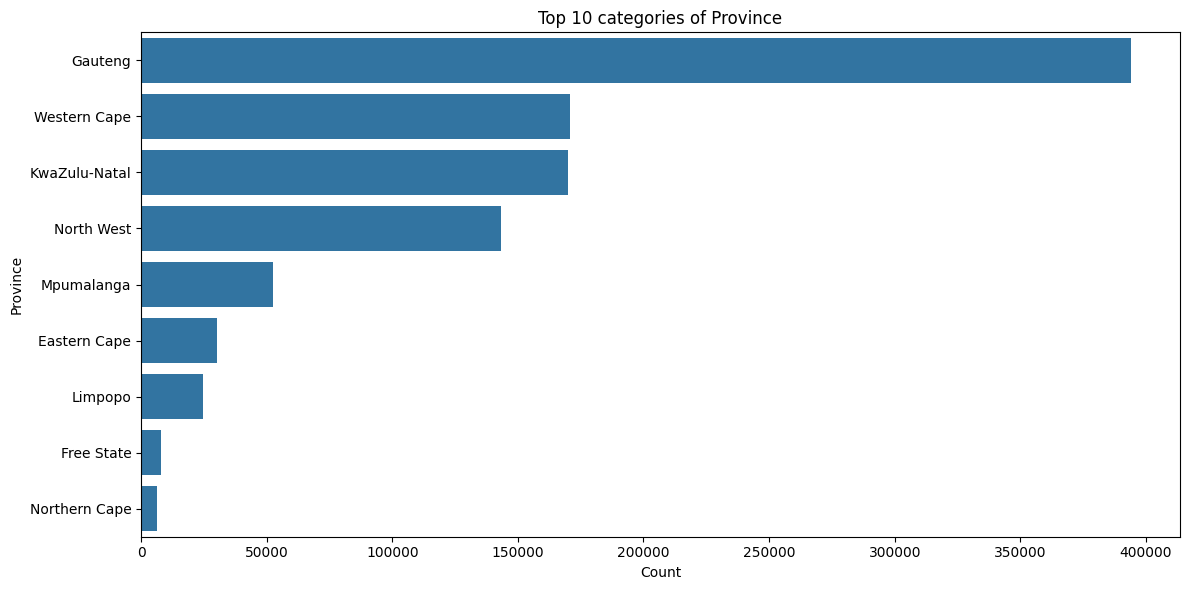

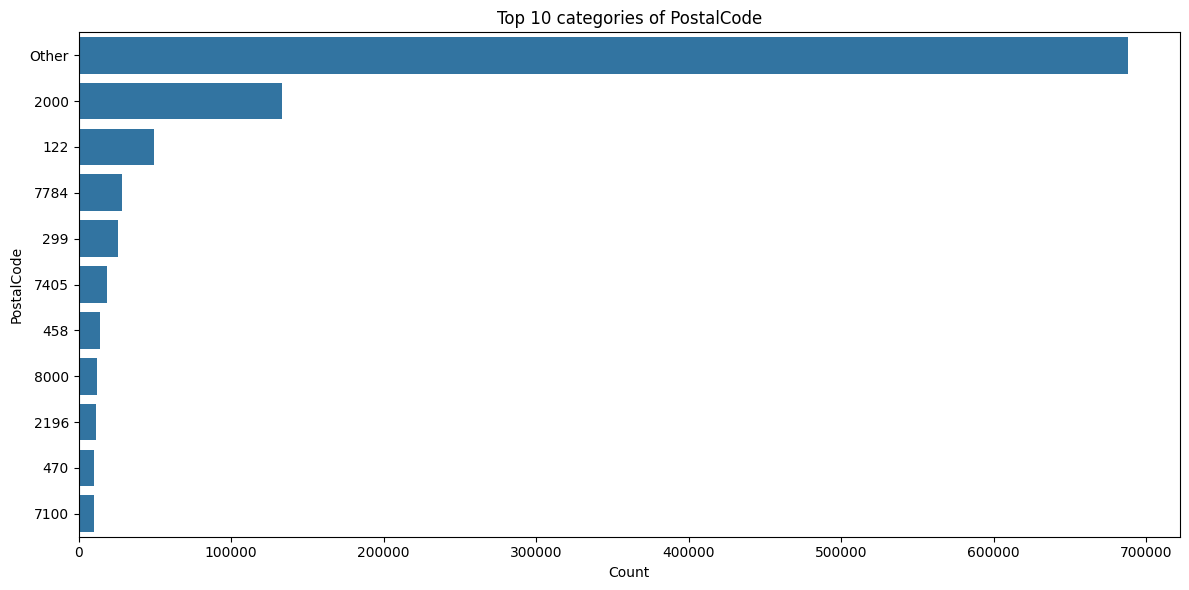

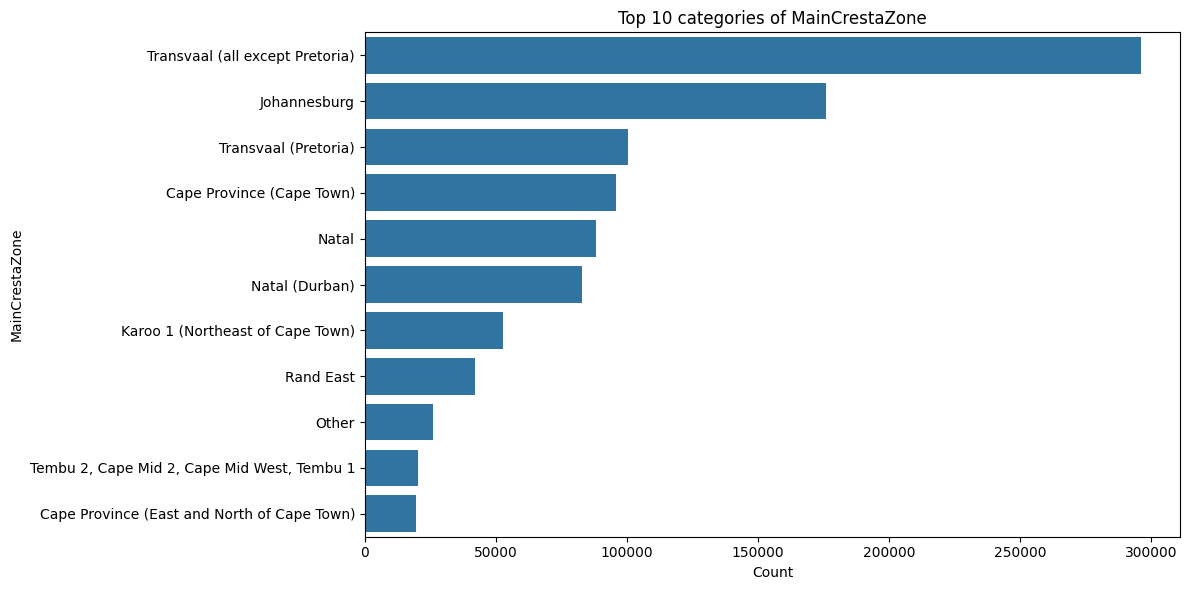

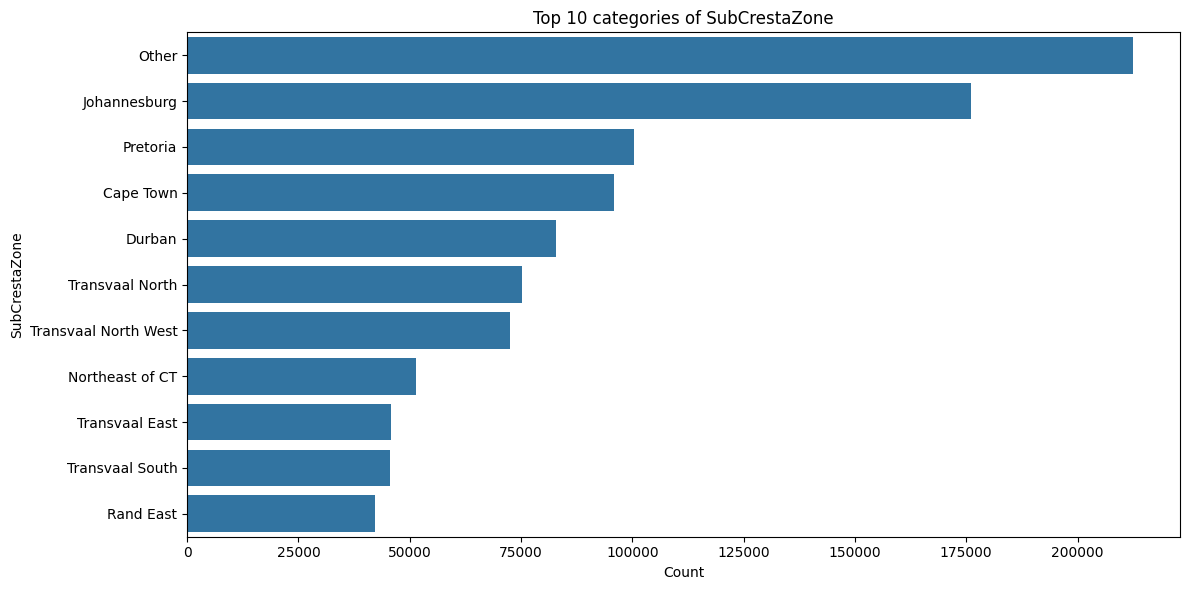

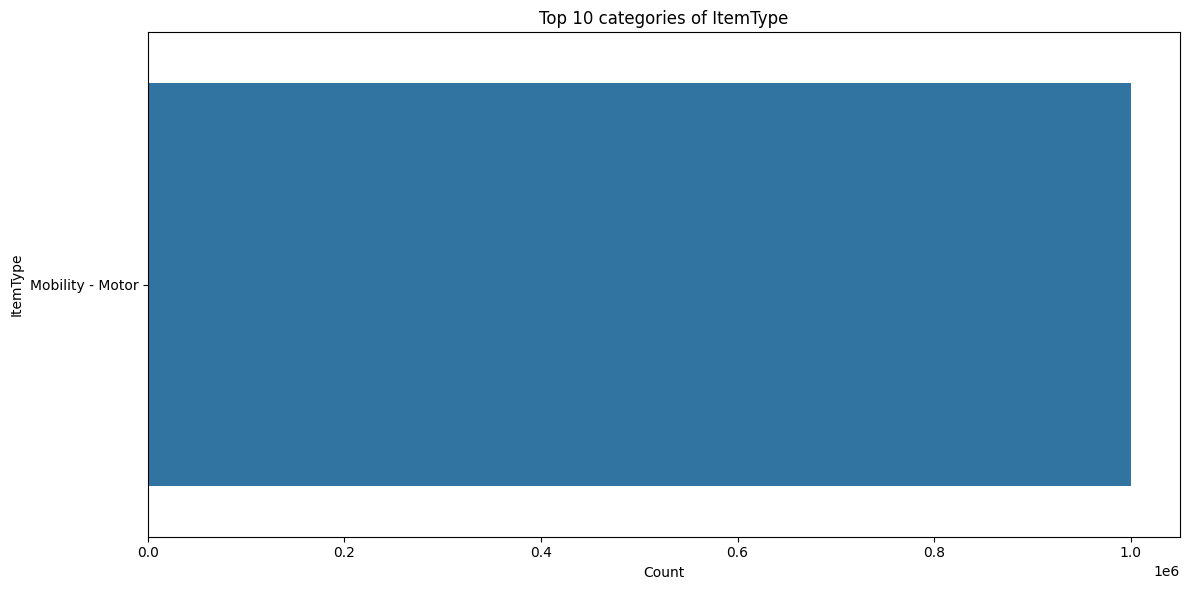

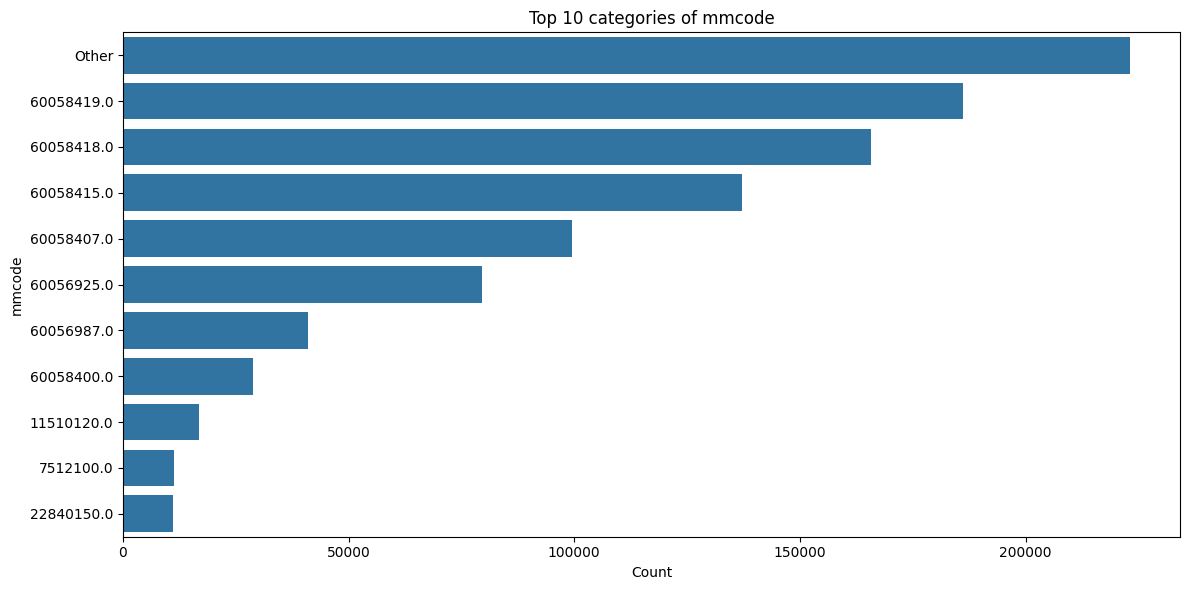

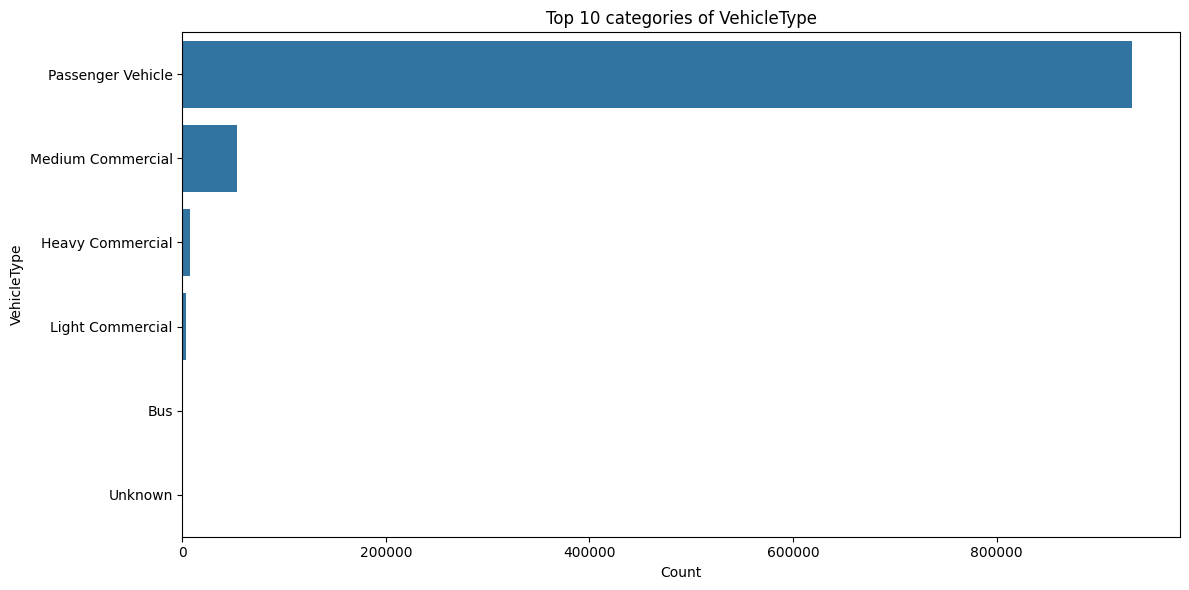

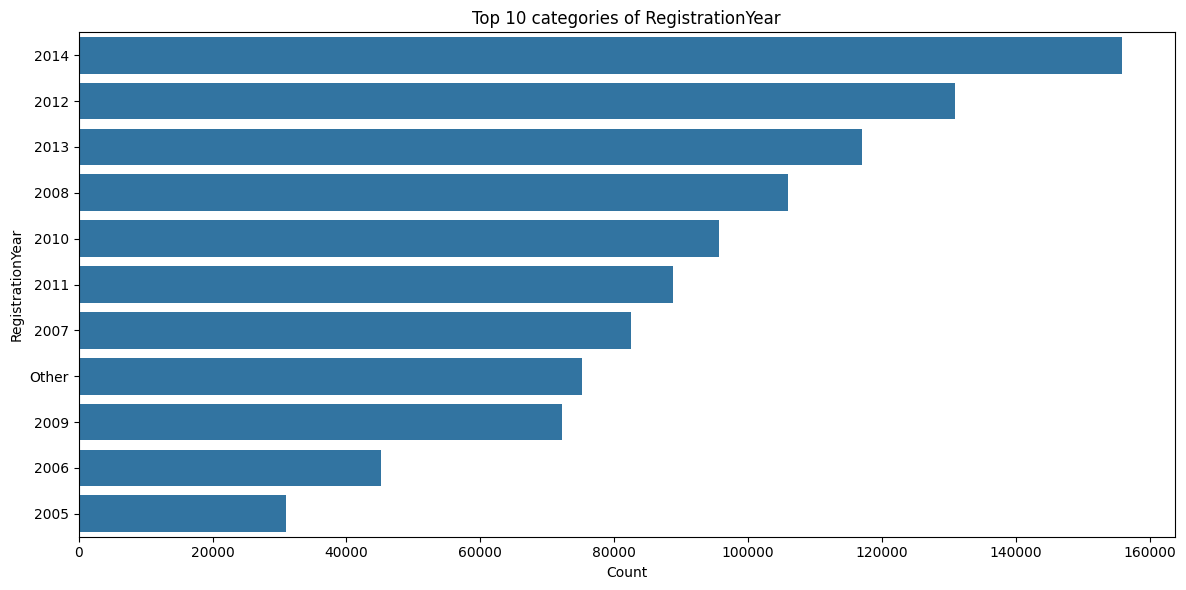

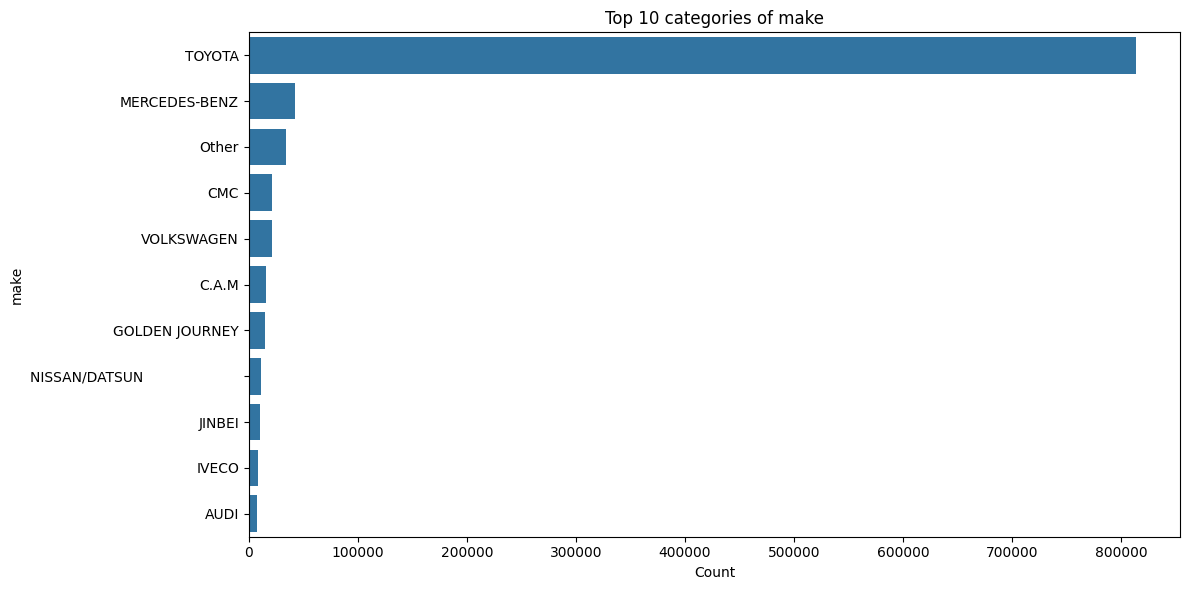

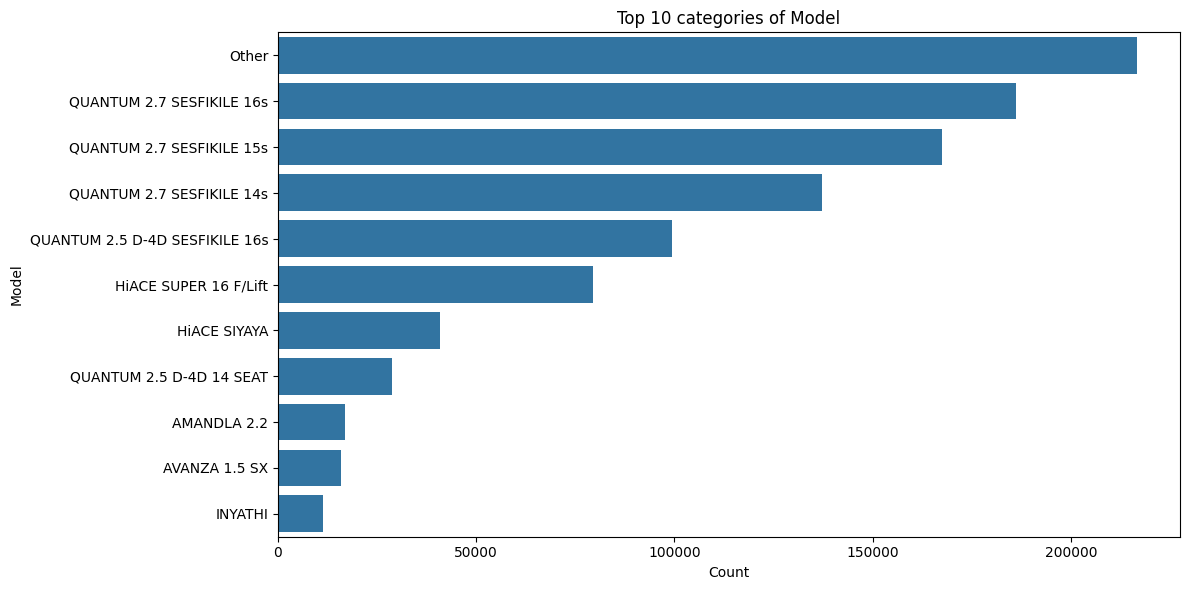

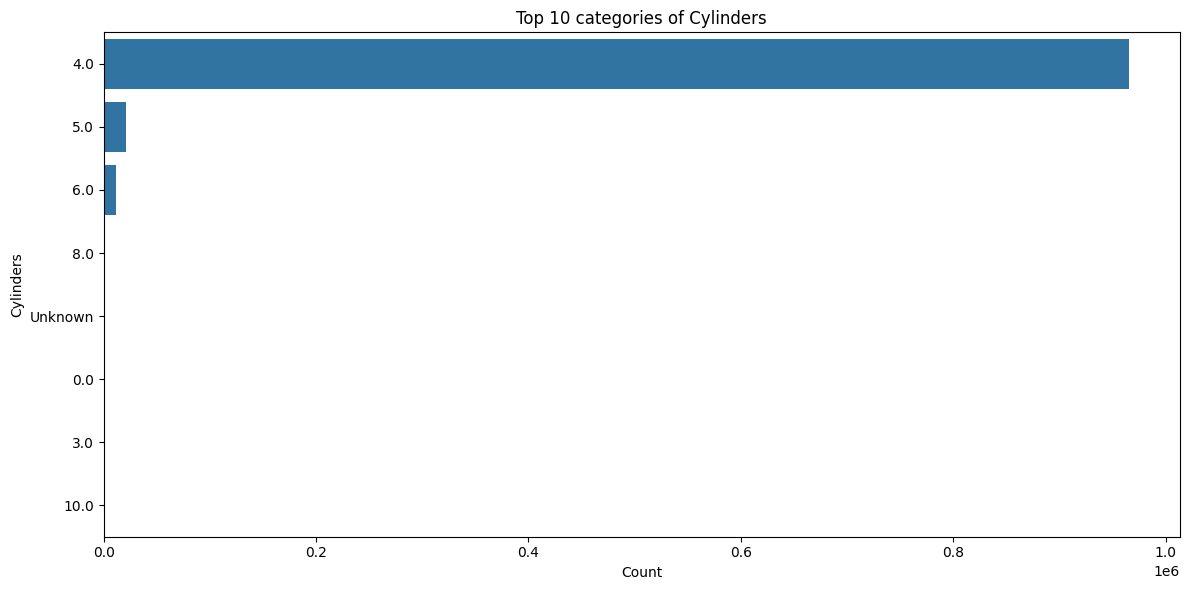

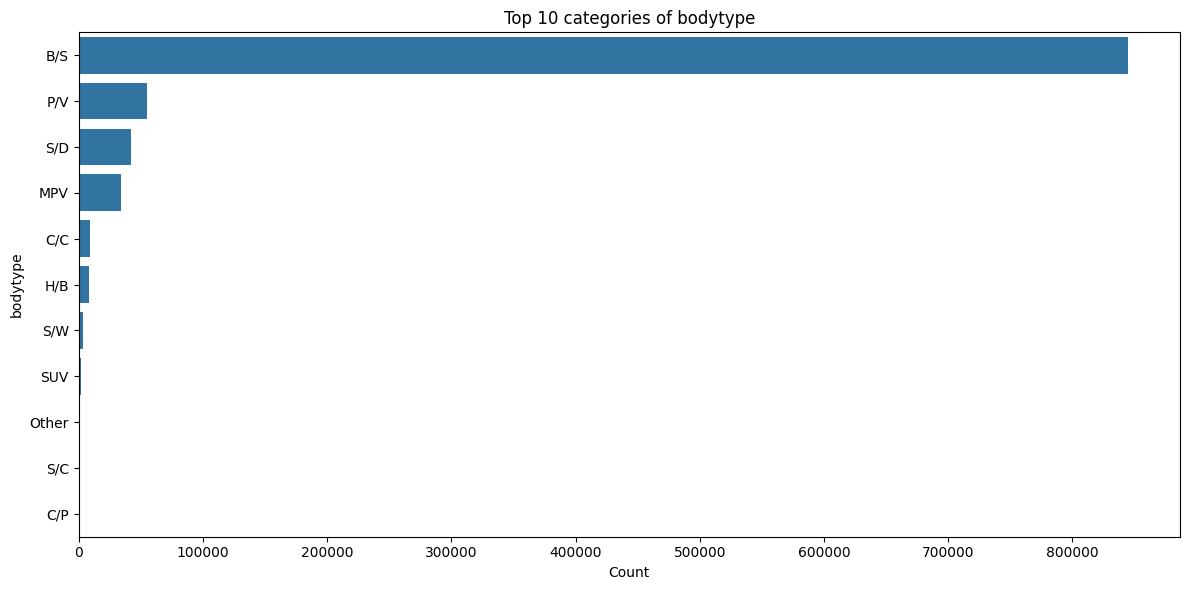

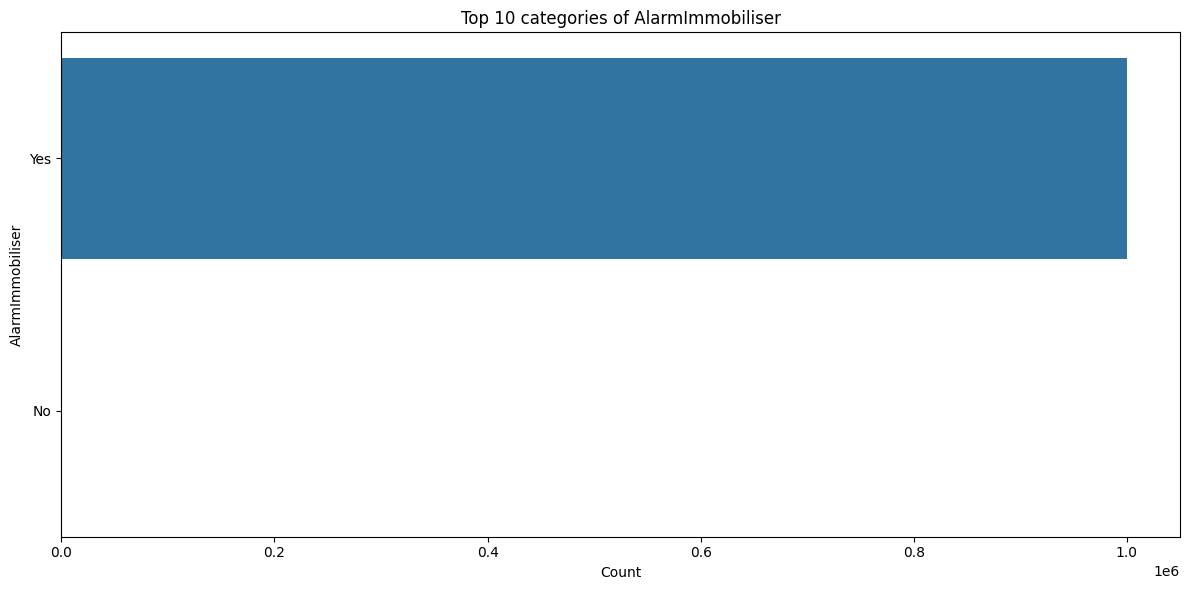

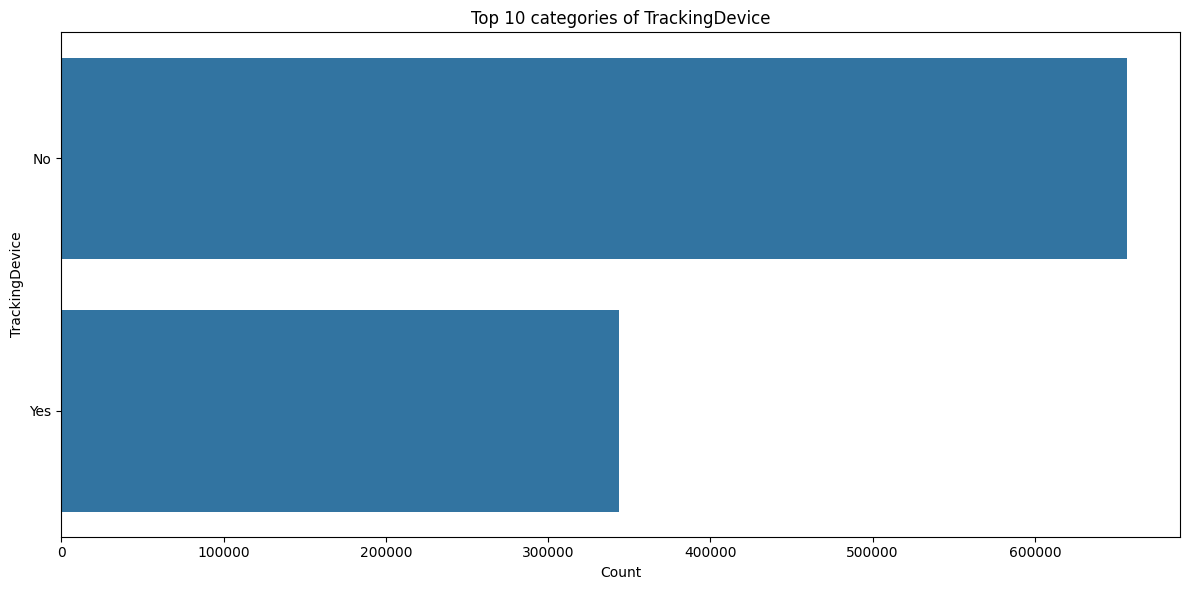

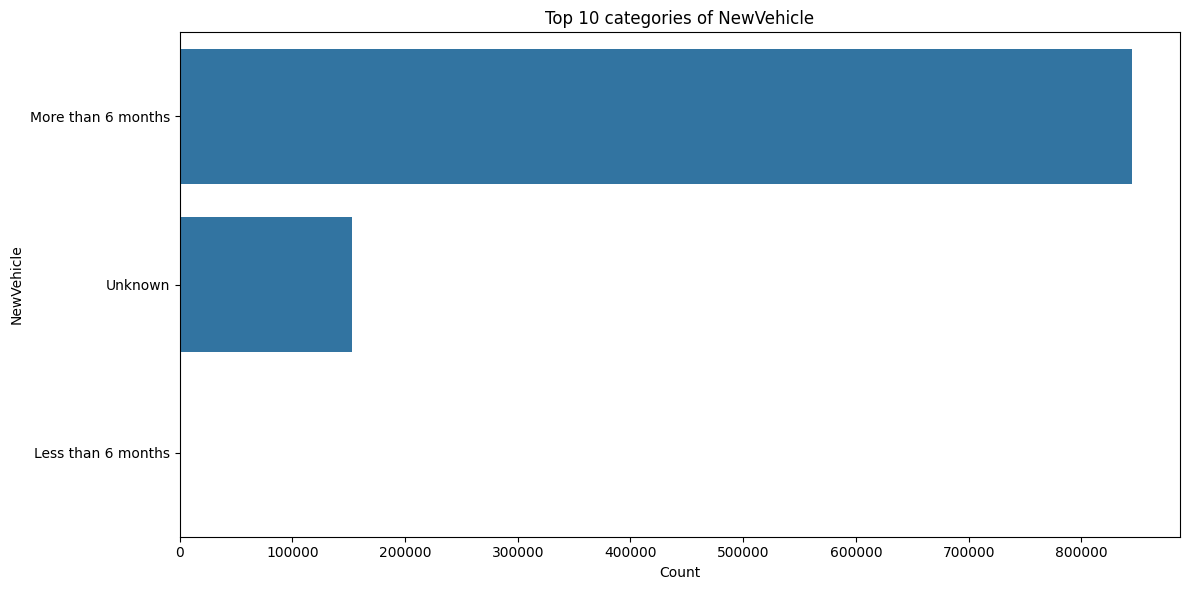

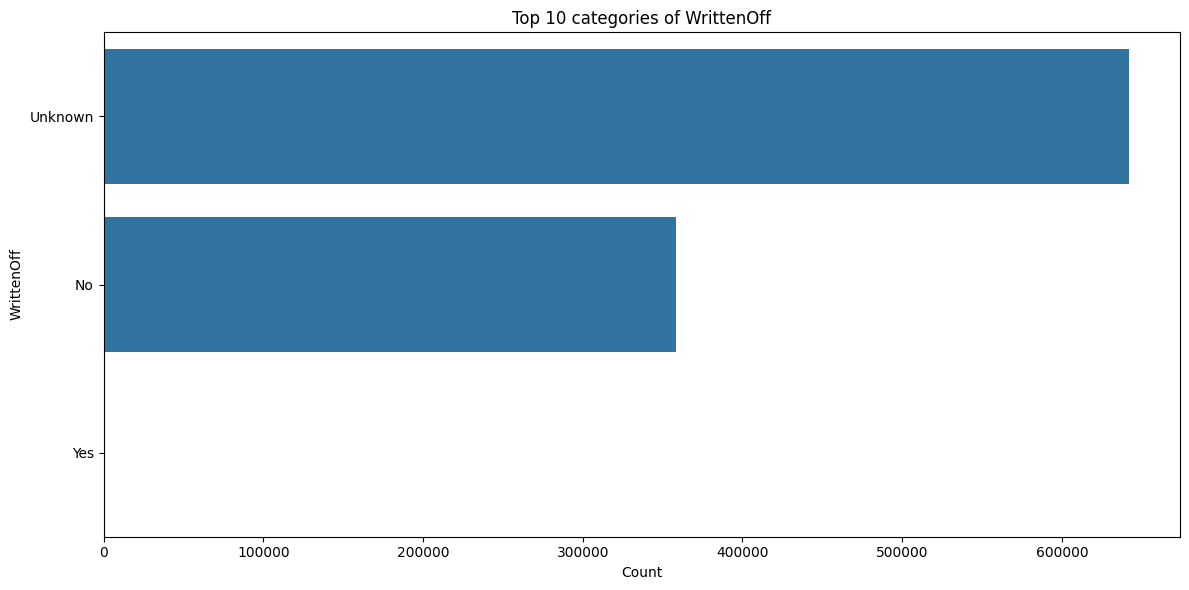

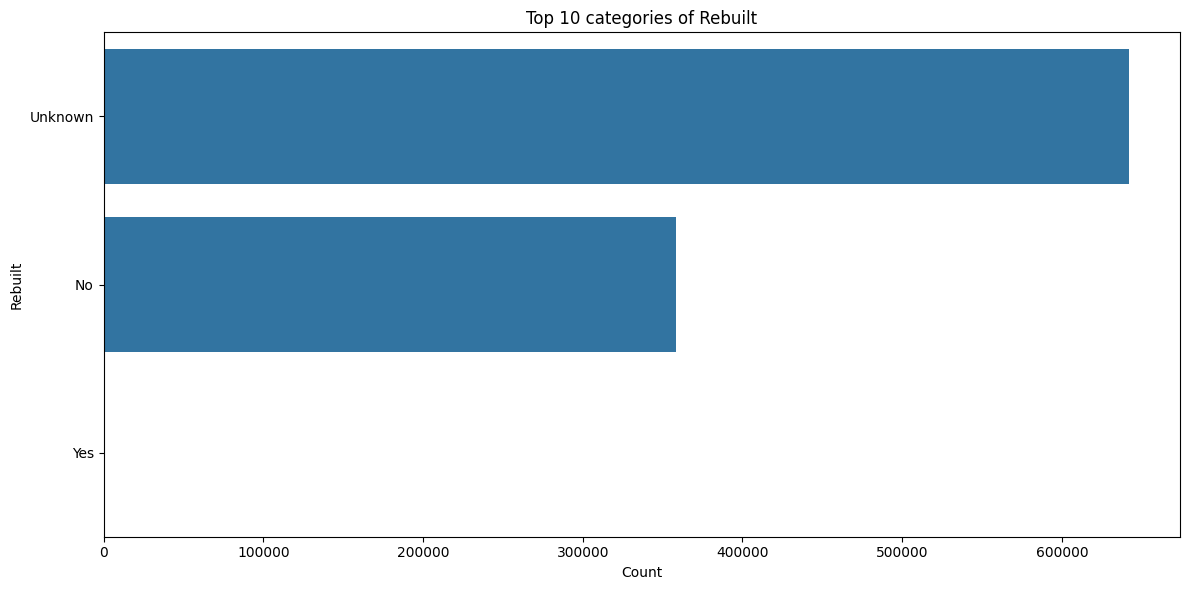

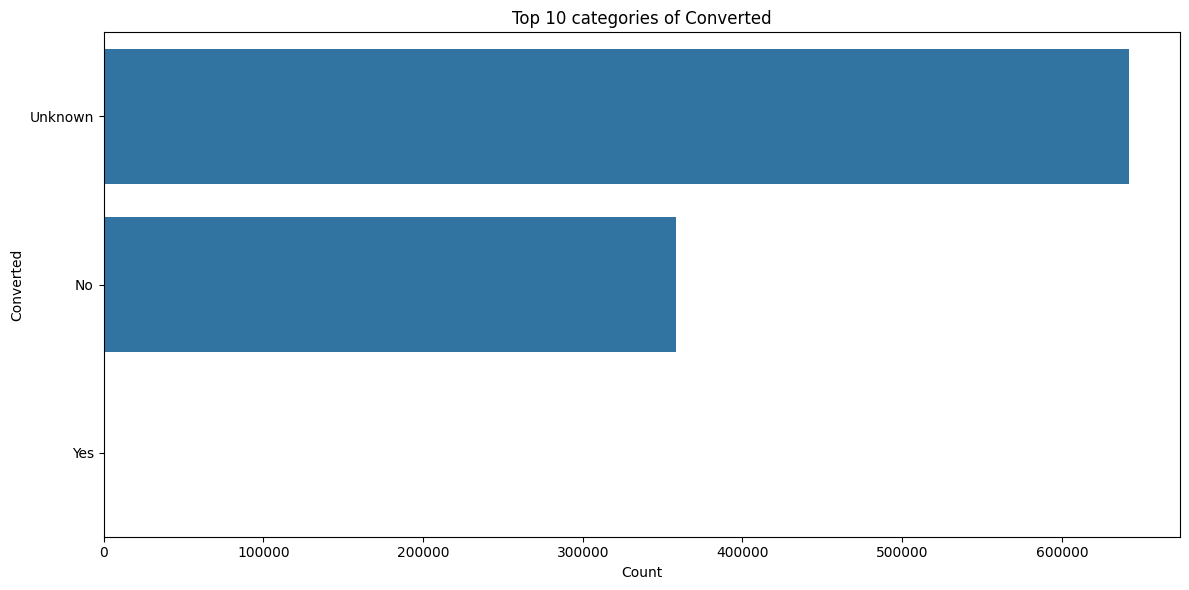

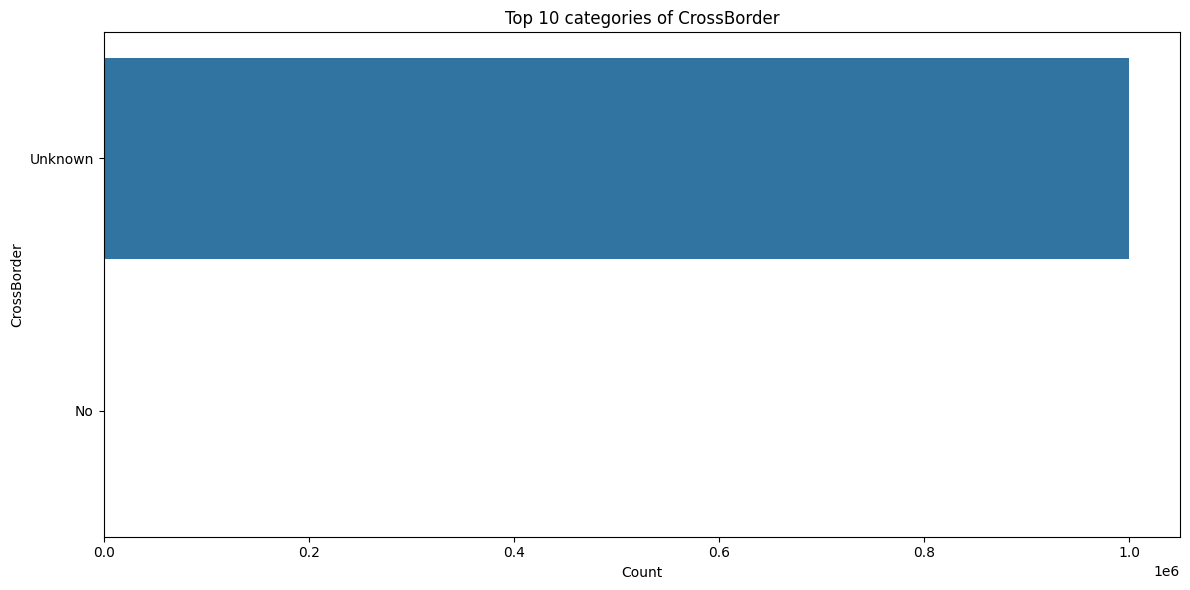

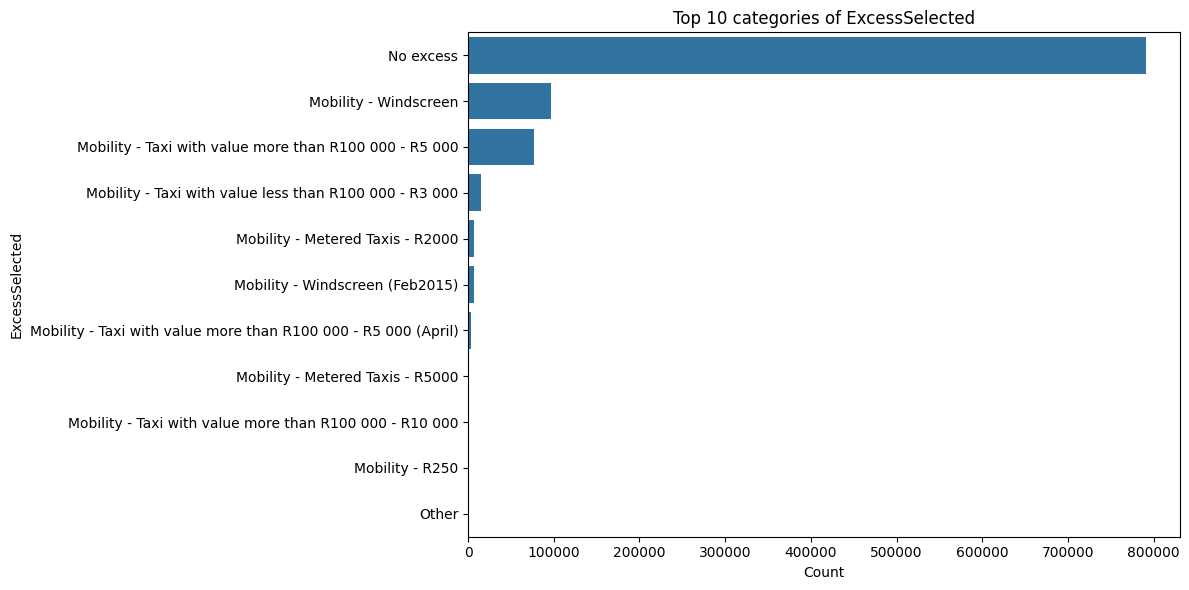

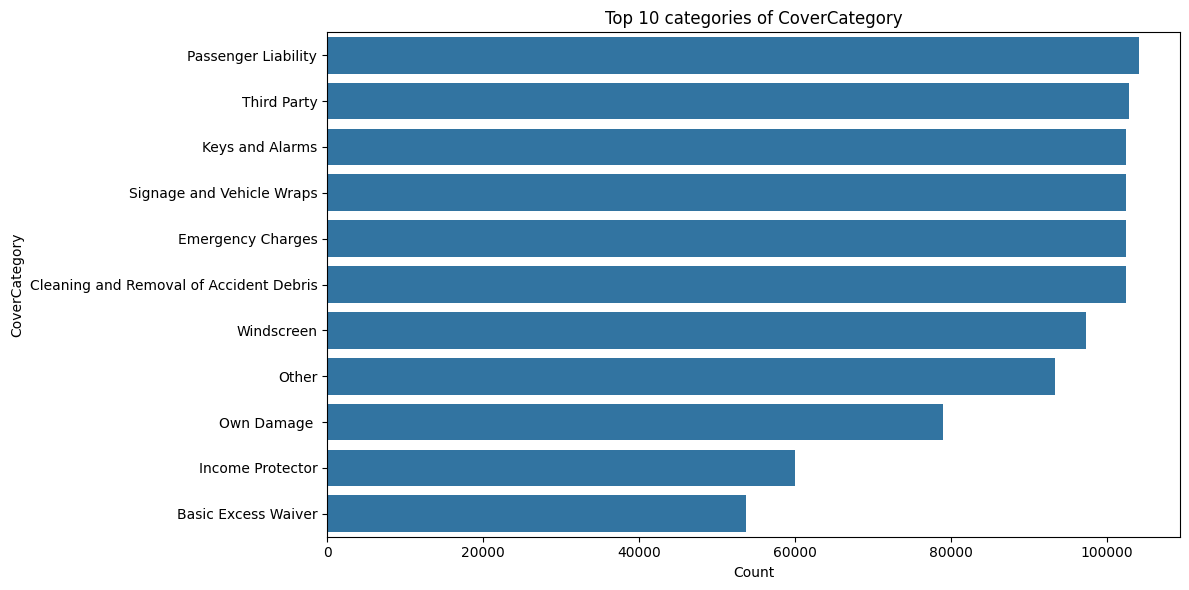

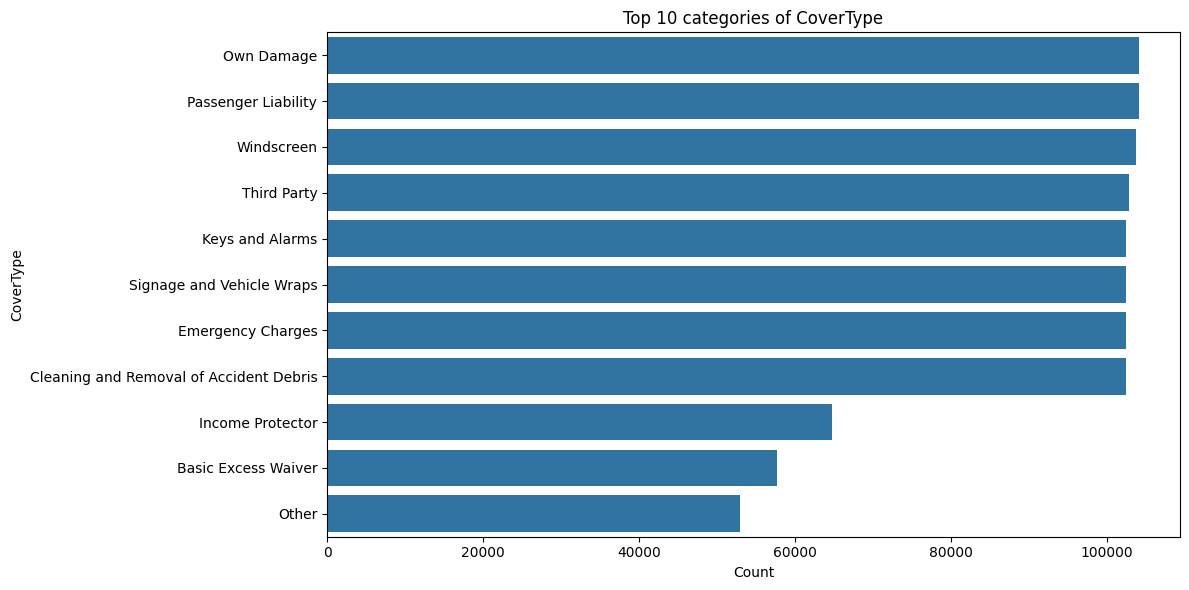

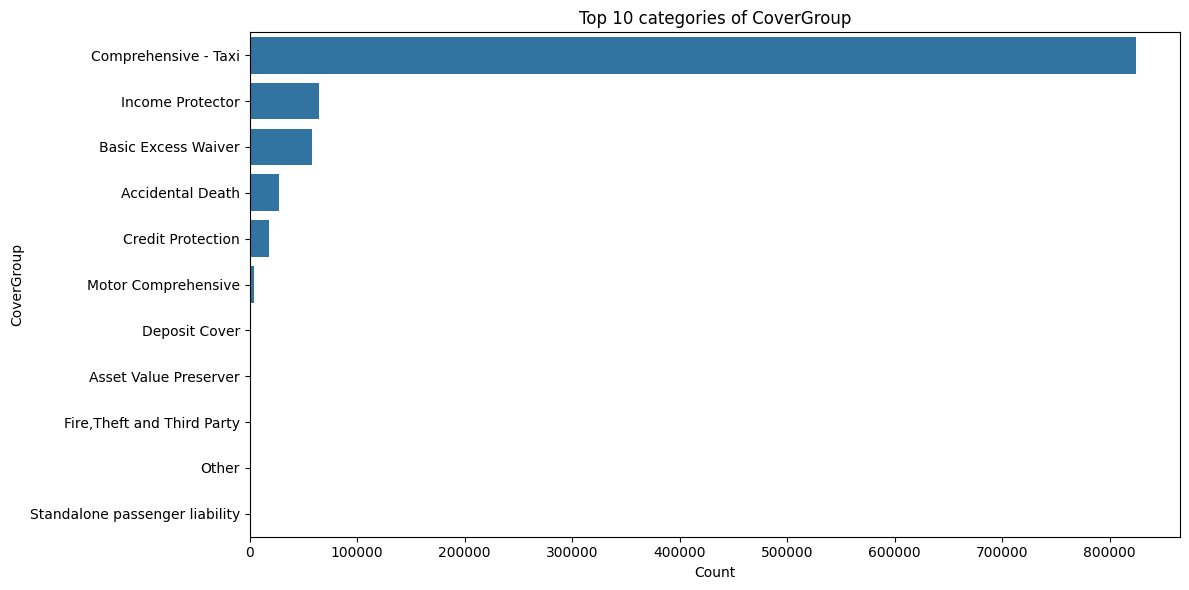

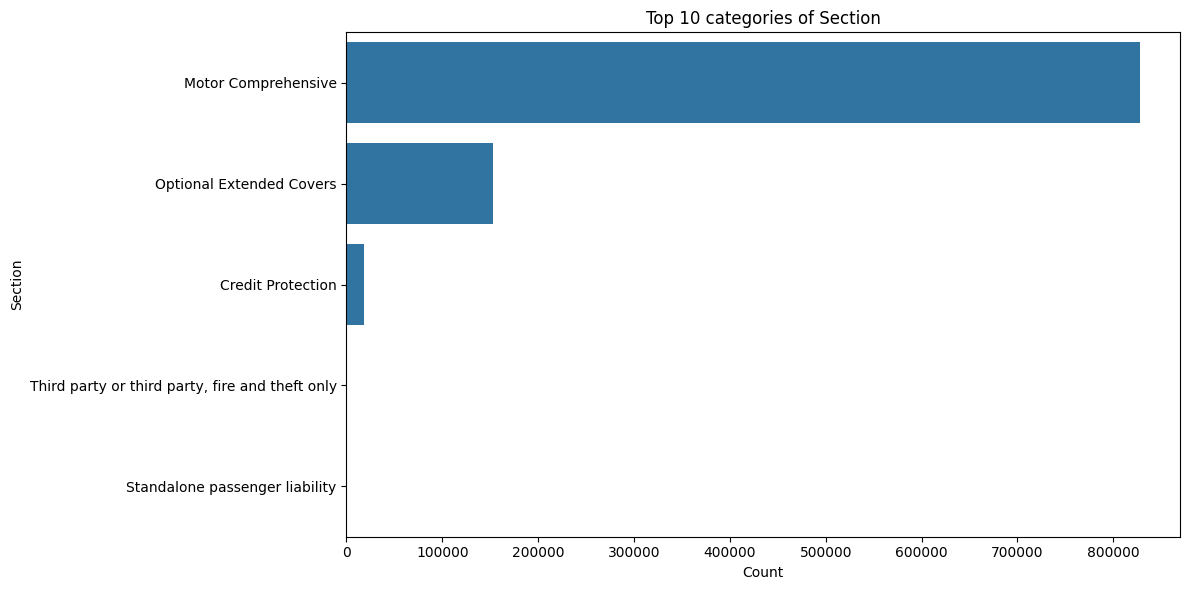

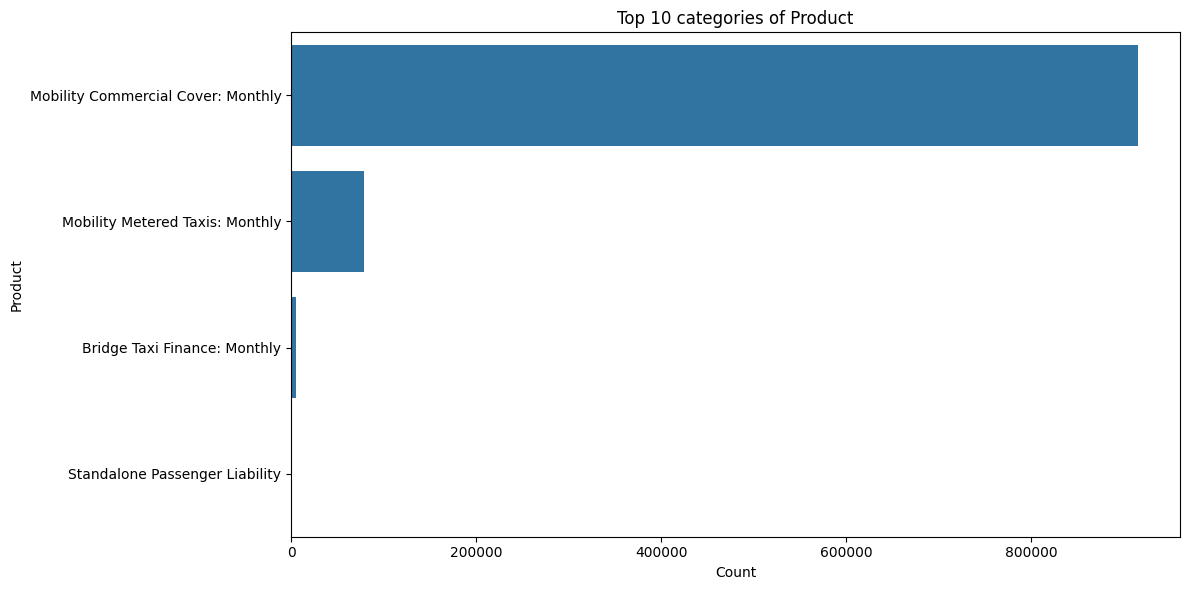

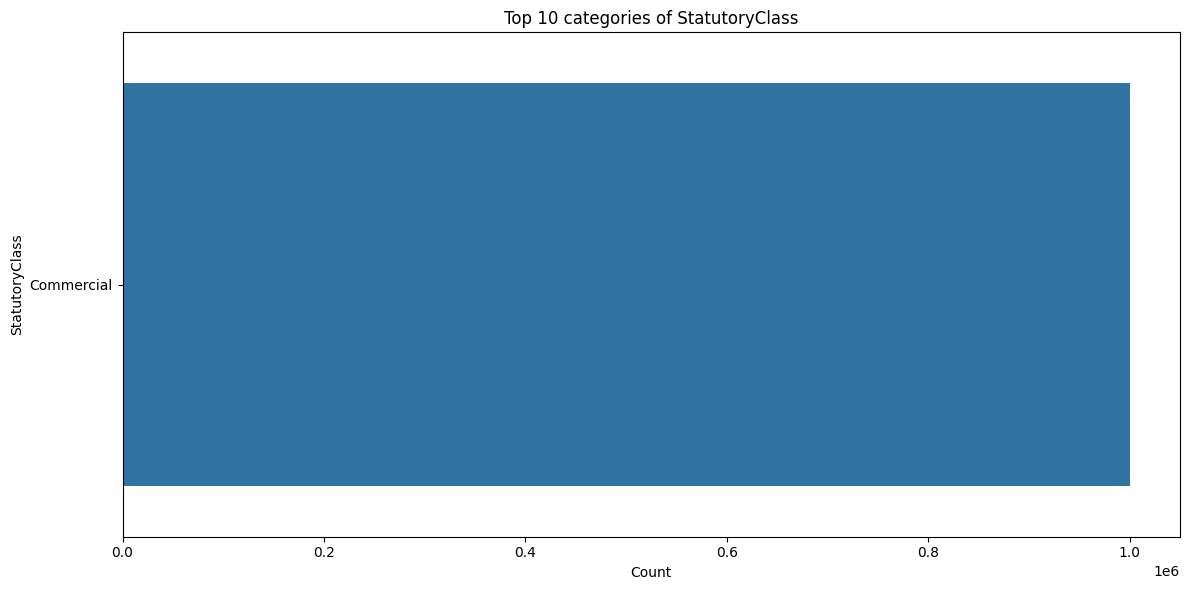

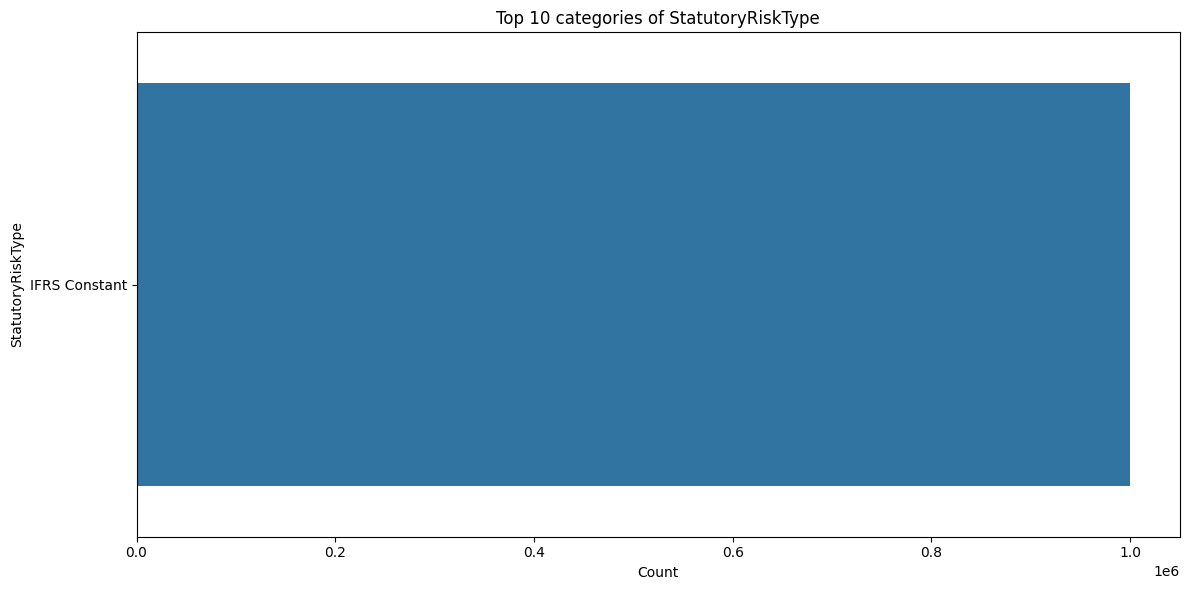

In [5]:
from src.data_processing.univariate import UnivariateAnalyzer

uni = UnivariateAnalyzer(df_cleaned)
uni.plot_all(top_n=10)


5 Multivariate Analysis

In [10]:
from src.data_processing.Multivariate import MultivariateAnalyzer

# Initialize analyzer
multi  = MultivariateAnalyzer(df_cleaned)


In [11]:
multi.compute_monthly_changes()

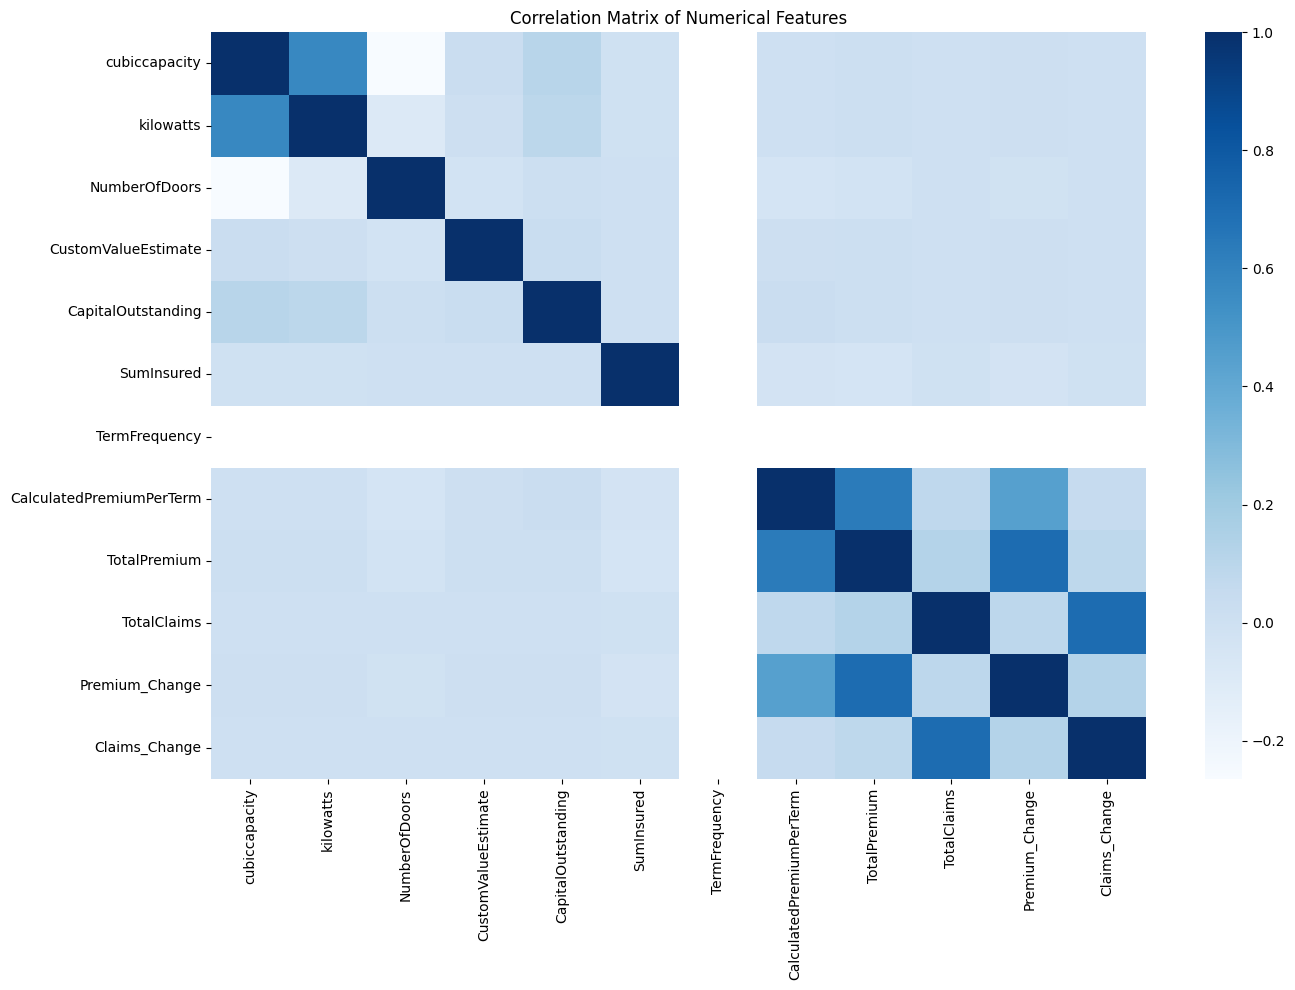

In [12]:
multi.correlation_matrix()

E:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\src\data_processing\Multivariate.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
e:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


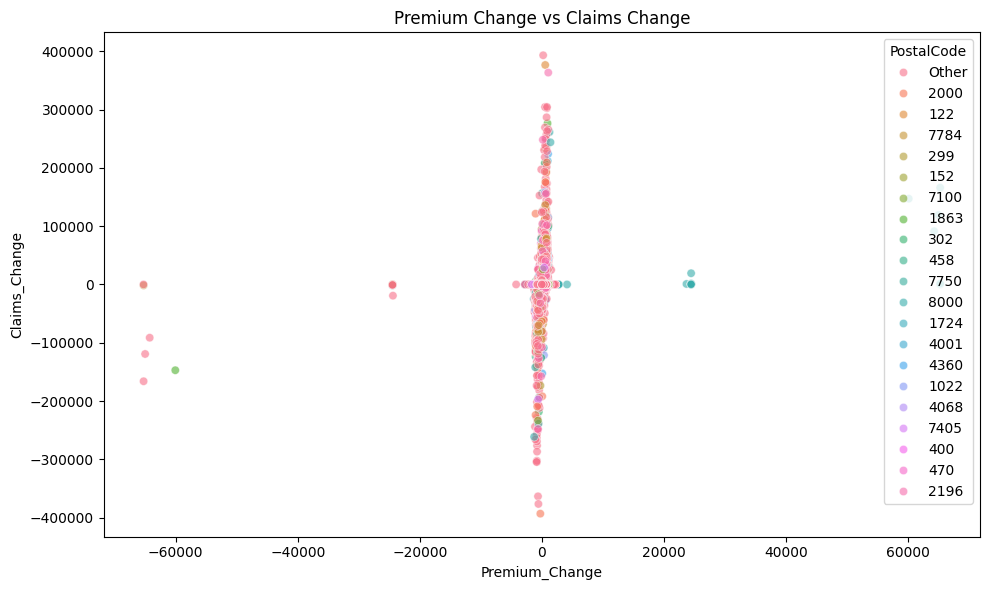

In [13]:
multi.scatter_premium_vs_claims("PostalCode", top_n=20)

E:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\src\data_processing\Multivariate.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
e:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


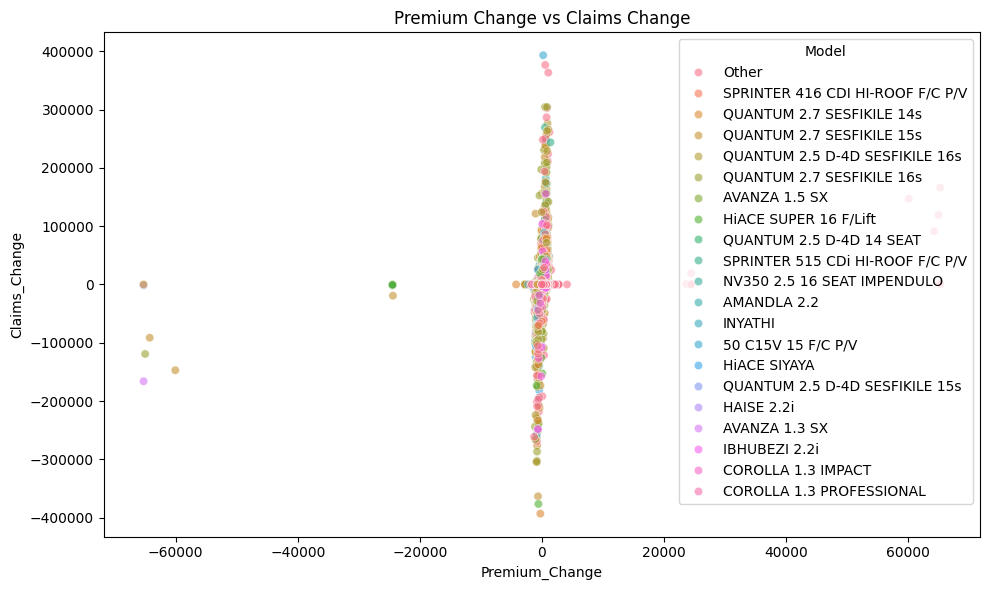

In [14]:
multi.scatter_premium_vs_claims("Model", top_n=20)

6 Data Comaprision

In [14]:
from src.data_processing.Data_comparision import GeographicAnalyzerTop10Postal

geo_cols_categorical = ["CoverType", "CoverGroup", "make", "Model"]
geo_cols_numeric = ["TotalPremium", "TotalClaims"]

geo = GeographicAnalyzerTop10Postal(
    df_cleaned,
    selected_categorical=geo_cols_categorical,
    selected_numeric=geo_cols_numeric
)

geo.run_all()


ImportError: cannot import name 'GeographicAnalyzerTop10Postal' from 'src.data_processing.Data_comparision' (E:\End-to-End-Insurance-Risk-Analytics-Predictive-Modeling-week_3\src\data_processing\Data_comparision.py)

7 Outlier Detection

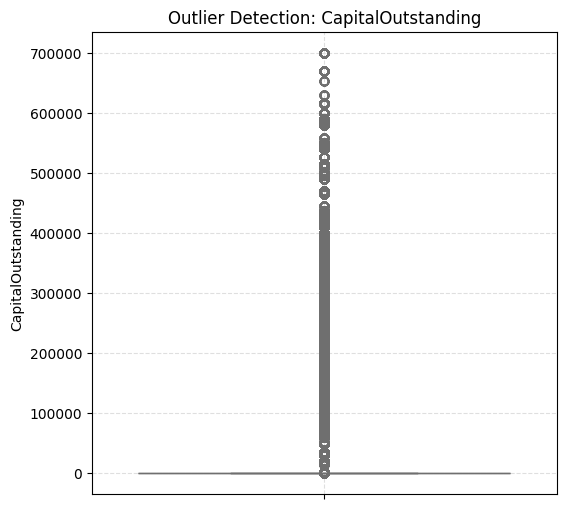

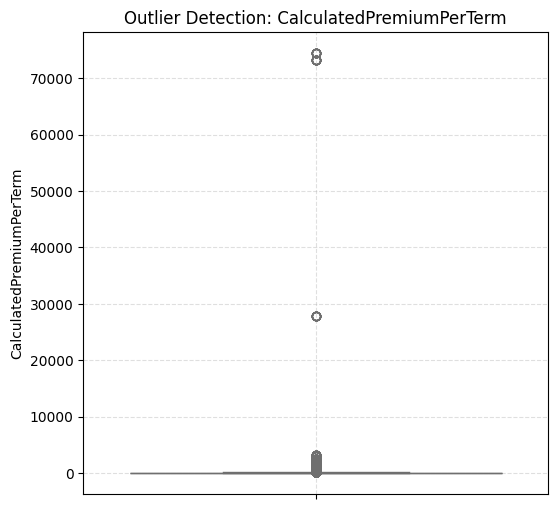

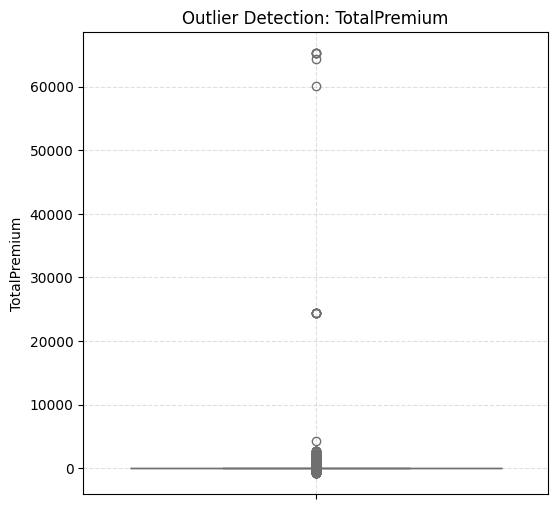

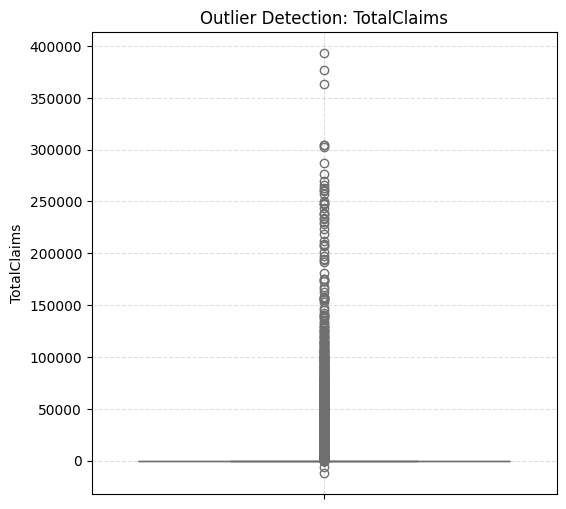

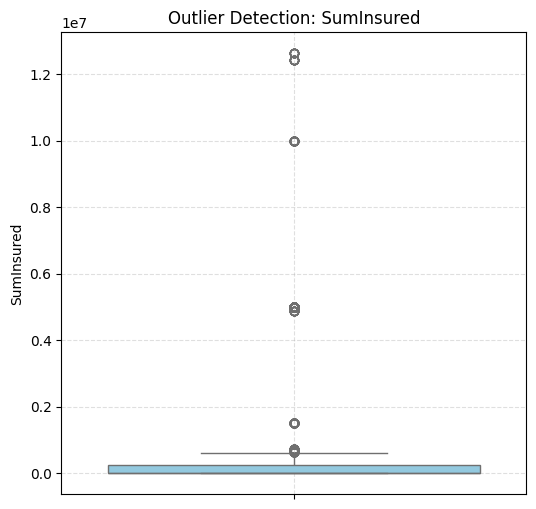

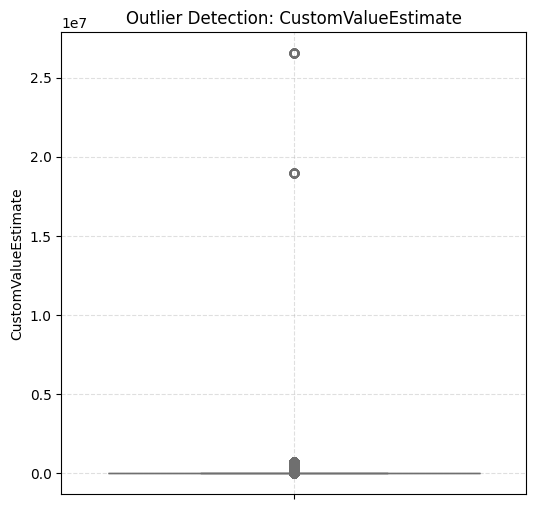

CapitalOutstanding has 206996 outliers
CalculatedPremiumPerTerm has 175508 outliers
TotalPremium has 209042 outliers
TotalClaims has 2793 outliers
SumInsured has 104294 outliers
CustomValueEstimate has 220456 outliers


In [7]:
from src.data_processing.Outlier_Detection import OutlierDetector   

# Create outlier detector object

numeric_cols = [
    "CapitalOutstanding",
    "CalculatedPremiumPerTerm",
    "TotalPremium",
    "TotalClaims",
    "SumInsured",
    "CustomValueEstimate"]
detector = OutlierDetector(df_cleaned, columns=numeric_cols)
# Plot boxplots for specified numeric columns
detector.plot_boxplots()

# Get outlier values
outliers = detector.get_outliers()
for col, values in outliers.items():
    print(f"{col} has {len(values)} outliers")


7 Visualziation

In [8]:
from src.data_processing.visualization import DataVisualizer

# Create visualizer instance
viz = DataVisualizer(df_cleaned)
viz.plot_monthly_premium_top_postal(top_n=5)

MemoryError: Unable to allocate 7.63 MiB for an array with shape (1000098,) and data type int64